2026-02-14 18:53:59 - INFO - Fetching Page 1...
2026-02-14 18:53:59 - INFO - GET https://api.gridstatus.io/v1/datasets/pjm_lmp_real_time_5_min/query
2026-02-14 18:53:59 - INFO - Params: {'start_time': Timestamp('2025-01-01 19:00:00+0000', tz='UTC'), 'end_time': Timestamp('2025-12-31 19:00:00+0000', tz='UTC'), 'publish_time_start': None, 'publish_time_end': None, 'limit': None, 'page': 1, 'page_size': None, 'resample_frequency': None, 'resample_by': None, 'resample_function': None, 'publish_time': None, 'timezone': None, 'cursor': '', 'filter_column': 'location', 'filter_value': 'WEST INT HUB', 'filter_operator': '=', 'return_format': 'json', 'json_schema': 'array-of-arrays'}
2026-02-14 18:54:17 - INFO - Done in 17.16 seconds. 
2026-02-14 18:54:17 - INFO - Fetching Page 2...
2026-02-14 18:54:17 - INFO - GET https://api.gridstatus.io/v1/datasets/pjm_lmp_real_time_5_min/query
2026-02-14 18:54:17 - INFO - Params: {'start_time': Timestamp('2025-01-01 19:00:00+0000', tz='UTC'), 'end_time': T

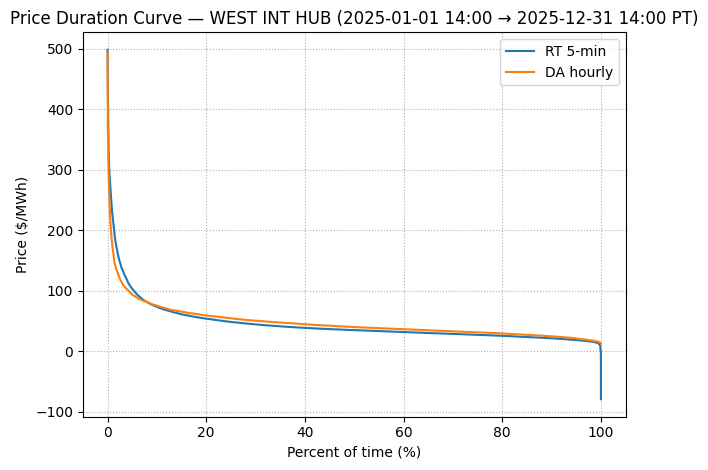

CSV files saved successfully.


In [68]:
from pyomo.environ import *
import pandas as pd
from gridstatusio import GridStatusClient
import numpy as np
import matplotlib.pyplot as plt

client = GridStatusClient(api_key="c4328bd041344b1693cdd97a432e529d")
QUERY_LIMIT = 10000

TZ = "America/New_York"

# Define the intended NYISO-local window
pt_start = pd.Timestamp("2025-01-01 14:00", tz=TZ)
pt_end   = pd.Timestamp("2025-12-31 14:00", tz=TZ)

# Convert to UTC for GridStatusClient
utc_start = pt_start.tz_convert("UTC").strftime("%Y-%m-%dT%H:%M:%SZ")
utc_end   = pt_end.tz_convert("UTC").strftime("%Y-%m-%dT%H:%M:%SZ")
df_RT_PJM = client.get_dataset(
    dataset= "pjm_lmp_real_time_5_min",
    start=utc_start,
    end=utc_end,
    filter_column = "location",
    filter_value = "WEST INT HUB",
)

df_DA_PJM = client.get_dataset(
    dataset= "pjm_lmp_day_ahead_hourly",
    start=utc_start,
    end=utc_end,
    filter_column = "location",
    filter_value = "WEST INT HUB",
)

def _sorted_desc(series_like):
    s = pd.Series(series_like).astype(float).dropna()
    return s.sort_values(ascending=False).reset_index(drop=True)

def plot_pdc(df_rt, df_da, price_col="lmp", label_rt="RT 5-min", label_da="DA hourly",
             title_extra="WEST INT HUB (2025-01-01 14:00 → 2025-12-31 14:00 PT)"):
    # Sort prices high→low
    s_rt = _sorted_desc(df_rt.loc[df_rt[price_col]<= 500,price_col])
    s_da = _sorted_desc(df_da.loc[df_da[price_col]<= 500,price_col])

    # X-axis as % of time covered
    x_rt = np.linspace(0, 100, len(s_rt), endpoint=False)
    x_da = np.linspace(0, 100, len(s_da), endpoint=False)

    # Plot both curves on the same axes
    plt.figure()
    plt.plot(x_rt, s_rt.values, label=label_rt)
    plt.plot(x_da, s_da.values, label=label_da)
    plt.xlabel("Percent of time (%)")
    plt.ylabel("Price ($/MWh)")
    plt.title(f"Price Duration Curve — {title_extra}")
    plt.legend()
    plt.grid(True, linestyle=":")
    plt.tight_layout()
    plt.show()

# Call it (uses your df_RT and df_DA)
plot_pdc(df_RT_PJM, df_DA_PJM)
# ---- Save full datasets to CSV ----
df_RT_PJM.to_csv(
    "df_RT_PJM_WEST INT HUB_2025_RT_5min.csv",
    index=False
)

df_DA_PJM.to_csv(
    "df_DA_PJM_WEST INT HUB_2025_DA_hourly.csv",
    index=False
)

print("CSV files saved successfully.")

2026-02-01 23:05:56 - INFO - Fetching Page 1...
2026-02-01 23:05:56 - INFO - GET https://api.gridstatus.io/v1/datasets/pjm_as_market_results_real_time/query
2026-02-01 23:05:56 - INFO - Params: {'start_time': Timestamp('2025-01-01 19:00:00+0000', tz='UTC'), 'end_time': Timestamp('2025-12-31 19:00:00+0000', tz='UTC'), 'publish_time_start': None, 'publish_time_end': None, 'limit': None, 'page': 1, 'page_size': None, 'resample_frequency': None, 'resample_by': None, 'resample_function': None, 'publish_time': None, 'timezone': None, 'cursor': '', 'filter_column': 'service_type', 'filter_value': 'Regulation', 'filter_operator': '=', 'return_format': 'json', 'json_schema': 'array-of-arrays'}
2026-02-01 23:05:58 - INFO - Done in 1.8 seconds. 
2026-02-01 23:05:58 - INFO - Fetching Page 2...
2026-02-01 23:05:58 - INFO - GET https://api.gridstatus.io/v1/datasets/pjm_as_market_results_real_time/query
2026-02-01 23:05:58 - INFO - Params: {'start_time': Timestamp('2025-01-01 19:00:00+0000', tz='UTC'

Columns: ['interval_start_utc', 'interval_end_utc', 'ancillary_service', 'locale', 'service_type', 'market_clearing_price', 'market_clearing_price_capped', 'regulation_capability_clearing_price', 'regulation_performance_clearing_price', 'ancillary_service_required', 'total_mw', 'assigned_mw', 'self_scheduled_mw', 'tier_1_mw', 'interface_reserve_capability_mw', 'demand_response_mw_assigned', 'non_synchronized_reserve_mw_assigned', 'regd_mw']
         interval_start_utc          interval_end_utc   ancillary_service  \
0 2025-01-01 19:00:00+00:00 2025-01-01 19:05:00+00:00  PJM_RTO-Regulation   
1 2025-01-01 19:05:00+00:00 2025-01-01 19:10:00+00:00  PJM_RTO-Regulation   
2 2025-01-01 19:10:00+00:00 2025-01-01 19:15:00+00:00  PJM_RTO-Regulation   
3 2025-01-01 19:15:00+00:00 2025-01-01 19:20:00+00:00  PJM_RTO-Regulation   
4 2025-01-01 19:20:00+00:00 2025-01-01 19:25:00+00:00  PJM_RTO-Regulation   

                 locale service_type  market_clearing_price  \
0  PJM RTO Reserve Zone   Reg

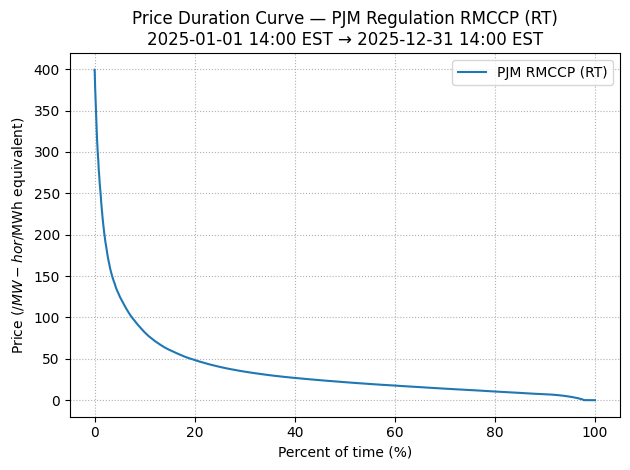

Saved: df_RMCCP_PJM_2025_RT.csv


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from gridstatusio import GridStatusClient

# -----------------------
# 0) SECURITY: don't hardcode keys in code
# -----------------------
# Better: export GRIDSTATUS_API_KEY in your environment and read it
client = GridStatusClient(api_key="9b41e6e3867c42dbbdccc14af42b5515")

TZ = "America/New_York"

pt_start = pd.Timestamp("2025-01-01 14:00", tz=TZ)
pt_end   = pd.Timestamp("2025-12-31 14:00", tz=TZ)

utc_start = pt_start.tz_convert("UTC").strftime("%Y-%m-%dT%H:%M:%SZ")
utc_end   = pt_end.tz_convert("UTC").strftime("%Y-%m-%dT%H:%M:%SZ")

# -----------------------
# 1) Download PJM RT AS results (Regulation)
# -----------------------
df = client.get_dataset(
    dataset="pjm_as_market_results_real_time",
    start=utc_start,
    end=utc_end,
    filter_column="service_type",
    filter_value="Regulation",
)

print("Columns:", list(df.columns))
print(df.head())

# -----------------------
# 2) Pick the RMCCP column
# -----------------------
# Option A (recommended): explicitly set it once you confirm the exact column name:
# price_col = "rmccp"

# Option B: try to auto-detect a likely price column:
candidates = [c for c in df.columns if "regulation_capability_clearing_price" in c.lower()]
if not candidates:
    raise ValueError(
        "Couldn't find an RMCCP column automatically. "
        "Set price_col manually after checking df.columns."
    )
price_col = candidates[0]
print("Using price_col =", price_col)

# -----------------------
# 3) Helper + PDC plot
# -----------------------
def _sorted_desc(series_like):
    s = pd.Series(series_like).astype(float).dropna()
    return s.sort_values(ascending=False).reset_index(drop=True)

def plot_pdc_one(df_in, price_col, label="PJM RMCCP (RT)", clip_max=400,
                 title_extra="PJM Regulation RMCCP (RT)"):
    # clean + optional clip
    s = pd.to_numeric(df_in[price_col], errors="coerce").dropna()
    if clip_max is not None:
        s = s[s <= clip_max]

    s_sorted = _sorted_desc(s)

    x = np.linspace(0, 100, len(s_sorted), endpoint=False)

    plt.figure()
    plt.plot(x, s_sorted.values, label=label)
    plt.xlabel("Percent of time (%)")
    plt.ylabel("Price ($/MW-h or $/MWh equivalent)")
    plt.title(f"Price Duration Curve — {title_extra}\n"
              f"{pt_start.strftime('%Y-%m-%d %H:%M %Z')} → {pt_end.strftime('%Y-%m-%d %H:%M %Z')}")
    plt.legend()
    plt.grid(True, linestyle=":")
    plt.tight_layout()
    plt.show()

plot_pdc_one(df, price_col=price_col)

# -----------------------
# 4) Save to CSV
# -----------------------
out_csv = "df_RMCCP_PJM_2025_RT.csv"
df.to_csv(out_csv, index=False)
print("Saved:", out_csv)

In [ ]:
from pyomo.environ import *
import pandas as pd
from gridstatusio import GridStatusClient
import numpy as np
import matplotlib.pyplot as plt

client = GridStatusClient(api_key="049071f2fbf54cf3b90ebe62aea819ee")
QUERY_LIMIT = 10000

TZ = "America/New_York"

# Define the intended NYISO-local window
pt_start = pd.Timestamp("2025-01-01 14:00", tz=TZ)
pt_end   = pd.Timestamp("2025-12-31 14:00", tz=TZ)

# Convert to UTC for GridStatusClient
utc_start = pt_start.tz_convert("UTC").strftime("%Y-%m-%dT%H:%M:%SZ")
utc_end   = pt_end.tz_convert("UTC").strftime("%Y-%m-%dT%H:%M:%SZ")
df_RT_PJM = client.get_dataset(
    dataset= "pjm_lmp_real_time_5_min",
    start=utc_start,
    end=utc_end,
    filter_column = "location",
    filter_value = "AECO",
)

df_DA_PJM = client.get_dataset(
    dataset= "pjm_lmp_day_ahead_hourly",
    start=utc_start,
    end=utc_end,
    filter_column = "location",
    filter_value = "AECO",
)

def _sorted_desc(series_like):
    s = pd.Series(series_like).astype(float).dropna()
    return s.sort_values(ascending=False).reset_index(drop=True)

def plot_pdc(df_rt, df_da, price_col="lmp", label_rt="RT 5-min", label_da="DA hourly",
             title_extra="AECO (2025-01-01 14:00 → 2025-12-31 14:00 PT)"):
    # Sort prices high→low
    s_rt = _sorted_desc(df_rt.loc[df_rt[price_col]<= 500,price_col])
    s_da = _sorted_desc(df_da.loc[df_da[price_col]<= 500,price_col])

    # X-axis as % of time covered
    x_rt = np.linspace(0, 100, len(s_rt), endpoint=False)
    x_da = np.linspace(0, 100, len(s_da), endpoint=False)

    # Plot both curves on the same axes
    plt.figure()
    plt.plot(x_rt, s_rt.values, label=label_rt)
    plt.plot(x_da, s_da.values, label=label_da)
    plt.xlabel("Percent of time (%)")
    plt.ylabel("Price ($/MWh)")
    plt.title(f"Price Duration Curve — {title_extra}")
    plt.legend()
    plt.grid(True, linestyle=":")
    plt.tight_layout()
    plt.show()

# Call it (uses your df_RT and df_DA)
plot_pdc(df_RT_PJM, df_DA_PJM)
# ---- Save full datasets to CSV ----
df_RT_PJM.to_csv(
    "df_RT_PJM_AECO_2025_RT_5min.csv",
    index=False
)

df_DA_PJM.to_csv(
    "df_DA_PJM_AECO_2025_DA_hourly.csv",
    index=False
)

print("CSV files saved successfully.")

DA columns: ['interval_start_utc', 'interval_end_utc', 'market', 'location', 'location_id', 'location_short_name', 'location_type', 'lmp', 'energy', 'congestion', 'loss']
RT columns: ['interval_start_utc', 'interval_end_utc', 'market', 'location', 'location_id', 'location_short_name', 'location_type', 'lmp', 'energy', 'congestion', 'loss']
[RT] using time col: 'interval_start_utc', price col: 'lmp'
[DA] using time col: 'interval_start_utc', price col: 'lmp'


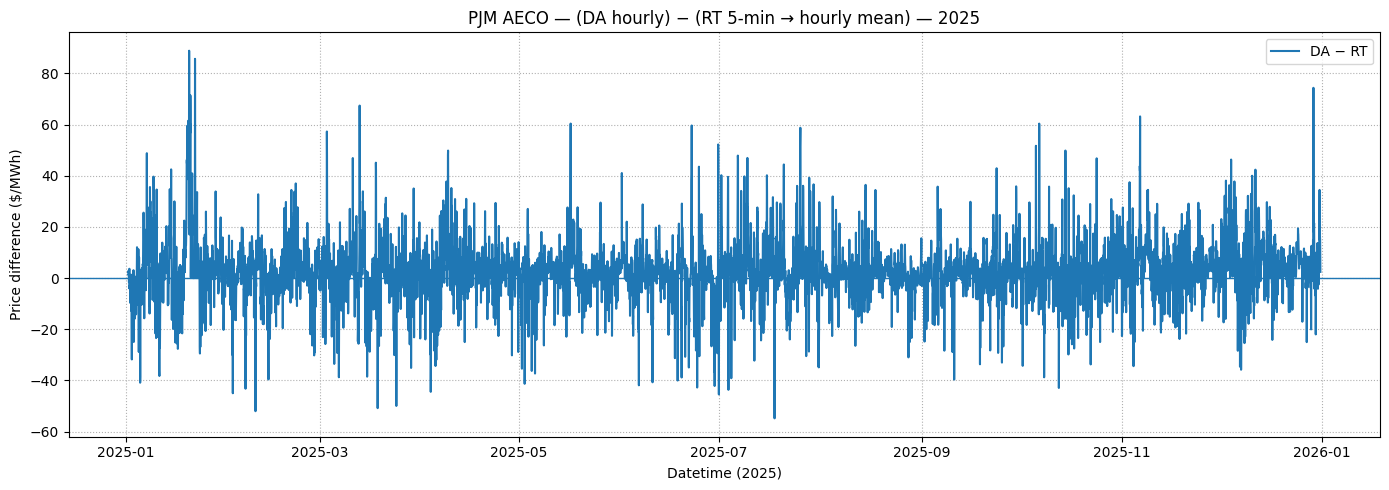

                           DA_hourly  RT_hourly_mean  DA_minus_RT
ts                                                               
2025-01-01 14:00:00-05:00  23.691925       21.279167     2.412758
2025-01-01 15:00:00-05:00  24.451535       21.710833     2.740702
2025-01-01 16:00:00-05:00  27.705767       26.209167     1.496600
2025-01-01 17:00:00-05:00  34.281031       33.096667     1.184364
2025-01-01 18:00:00-05:00  34.072148       32.565833     1.506315


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


def load_table(path: str) -> pd.DataFrame:
    """Load CSV / XLS / XLSX based on extension."""
    p = path.lower()
    if p.endswith(".csv"):
        return pd.read_csv(path)
    if p.endswith((".xls", ".xlsx")):
        return pd.read_excel(path)
    raise ValueError(f"Unsupported file type: {path}")


def plot_da_minus_rt(
    df_rt,
    df_da,
    price_col="lmp",
    clip_low=-500,
    clip_high=500,
    tz_plot="America/New_York",
    rt_hourly_method="mean",   # "mean" | "median" | "last"
    title="PJM AECO — (DA hourly) − (RT 5-min → hourly) — 2025",
    verbose=True,
):
    """
    Plots the time-aligned difference:
        diff(t) = DA_hourly(t) - RT_hourly(t)
    where RT_hourly is RT 5-min resampled to hourly (mean/median/last).
    Prices are clipped to [clip_low, clip_high] BEFORE differencing.
    """

    # --- Find a datetime column robustly ---
    def _get_time_col(df):
        for c in ["interval_start_utc", "interval_start", "time", "timestamp", "datetime"]:
            if c in df.columns:
                return c
        for c in df.columns:
            try:
                if np.issubdtype(df[c].dtype, np.datetime64):
                    return c
            except Exception:
                pass
        raise ValueError("No datetime column found. Columns:\n" + ", ".join(map(str, df.columns)))

    # --- Choose a price column robustly (case-insensitive + fallbacks) ---
    def _pick_price_col(df, preferred):
        if preferred in df.columns:
            return preferred

        lower_map = {c.lower(): c for c in df.columns if isinstance(c, str)}
        if preferred.lower() in lower_map:
            return lower_map[preferred.lower()]

        candidates = [
            "price",
            "lmp",
            "LMP",
            "da_lmp",
            "rt_lmp",
            "market_price",
            "lbmp",
            "mp",
            "value",
        ]
        for c in candidates:
            if c in df.columns:
                return c
            if isinstance(c, str) and c.lower() in lower_map:
                return lower_map[c.lower()]

        numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        for c in numeric_cols:
            if str(c).lower() not in {"year", "month", "day", "hour", "minute"}:
                return c

        raise KeyError(
            f"Could not find a price column. Preferred '{preferred}' not found.\n"
            f"Columns are:\n{list(df.columns)}"
        )

    rt_time_col = _get_time_col(df_rt)
    da_time_col = _get_time_col(df_da)

    rt_price_col = _pick_price_col(df_rt, price_col)
    da_price_col = _pick_price_col(df_da, price_col)

    if verbose:
        print(f"[RT] using time col: '{rt_time_col}', price col: '{rt_price_col}'")
        print(f"[DA] using time col: '{da_time_col}', price col: '{da_price_col}'")

    # --- Prep RT ---
    rt = df_rt[[rt_time_col, rt_price_col]].copy()
    rt[rt_time_col] = pd.to_datetime(rt[rt_time_col], utc=True, errors="coerce")
    rt = rt.dropna(subset=[rt_time_col, rt_price_col]).sort_values(rt_time_col)
    rt["ts"] = rt[rt_time_col].dt.tz_convert(tz_plot)
    rt["price"] = pd.to_numeric(rt[rt_price_col], errors="coerce").clip(lower=clip_low, upper=clip_high)
    rt = rt.dropna(subset=["price"]).set_index("ts")[["price"]]

    # RT 5-min -> hourly
    if rt_hourly_method == "mean":
        rt_h = rt.resample("h").mean()
    elif rt_hourly_method == "median":
        rt_h = rt.resample("h").median()
    elif rt_hourly_method == "last":
        rt_h = rt.resample("h").last()
    else:
        raise ValueError("rt_hourly_method must be one of: mean, median, last")

    rt_h = rt_h.rename(columns={"price": f"RT_hourly_{rt_hourly_method}"})

    # --- Prep DA ---
    da = df_da[[da_time_col, da_price_col]].copy()
    da[da_time_col] = pd.to_datetime(da[da_time_col], utc=True, errors="coerce")
    da = da.dropna(subset=[da_time_col, da_price_col]).sort_values(da_time_col)
    da["ts"] = da[da_time_col].dt.tz_convert(tz_plot)
    da["price"] = pd.to_numeric(da[da_price_col], errors="coerce").clip(lower=clip_low, upper=clip_high)
    da = da.dropna(subset=["price"]).set_index("ts")[["price"]].rename(columns={"price": "DA_hourly"})

    # Normalize DA to hourly
    da_h = da.resample("h").mean()

    # --- Align + compute difference ---
    merged = da_h.join(rt_h, how="inner")
    merged["DA_minus_RT"] = merged["DA_hourly"] - merged[f"RT_hourly_{rt_hourly_method}"]

    # --- Plot ---
    plt.figure(figsize=(14, 5))
    plt.plot(merged.index, merged["DA_minus_RT"], label="DA − RT")
    plt.axhline(0, linewidth=1)
    plt.xlabel("Datetime (2025)")
    plt.ylabel("Price difference ($/MWh)")
    plt.title(title)
    plt.grid(True, linestyle=":")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return merged


# =========================
# Load saved PJM DA/RT files (CSV or Excel) — NO API calls
# =========================

# Option B: absolute paths (raw strings) — uncomment if you prefer
da_path = r"C:\Users\hsofi\EVC\df_DA_PJM_AECO_2025_DA_hourly.csv"
rt_path = r"C:\Users\hsofi\EVC\df_RT_PJM_AECO_2025_RT_5min.csv"

df_DA = load_table(da_path)
df_RT = load_table(rt_path)

print("DA columns:", df_DA.columns.tolist())
print("RT columns:", df_RT.columns.tolist())


# =========================
# Run (PJM example)
# =========================
diff_df = plot_da_minus_rt(
    df_rt=df_RT,
    df_da=df_DA,
    price_col="lmp",
    clip_low=-100,
    clip_high=100,
    tz_plot="America/New_York",
    rt_hourly_method="mean",
    title="PJM AECO — (DA hourly) − (RT 5-min → hourly mean) — 2025",
    verbose=True,
)

print(diff_df.head())

In [8]:
def dart_extreme_metrics(
    diff_df: pd.DataFrame,
    dart_col="DA_minus_RT",
    threshold=30.0,
):
    """
    Quantify frequency and magnitude of extreme DART spreads.

    Returns a dict of metrics.
    """

    x = diff_df[dart_col].dropna()
    n = len(x)

    if n == 0:
        raise ValueError("No valid DART values found.")

    pos = x[x > threshold]
    neg = x[x < -threshold]
    extreme = x[np.abs(x) > threshold]

    metrics = {
        # ---- counts ----
        "n_hours_total": n,
        "n_hours_DART_gt_30": len(pos),
        "n_hours_DART_lt_-30": len(neg),
        "n_hours_abs_DART_gt_30": len(extreme),

        # ---- frequencies ----
        "pct_hours_DART_gt_30": 100 * len(pos) / n,
        "pct_hours_DART_lt_-30": 100 * len(neg) / n,
        "pct_hours_abs_DART_gt_30": 100 * len(extreme) / n,

        # ---- magnitudes (conditional) ----
        "mean_DART_gt_30": pos.mean() if len(pos) > 0 else np.nan,
        "mean_DART_lt_-30": neg.mean() if len(neg) > 0 else np.nan,
        "max_DART": x.max(),
        "min_DART": x.min(),

        # ---- aggregate severity ----
        "sum_abs_DART_gt_30": np.abs(extreme).sum(),
        "mean_abs_DART_gt_30": np.abs(extreme).mean() if len(extreme) > 0 else np.nan,
    }

    return metrics
dart_metrics = dart_extreme_metrics(
    diff_df,
    dart_col="DA_minus_RT",
    threshold=30,
)

pd.Series(dart_metrics)


n_hours_total               8734.000000
n_hours_DART_gt_30           152.000000
n_hours_DART_lt_-30           64.000000
n_hours_abs_DART_gt_30       216.000000
pct_hours_DART_gt_30           1.740325
pct_hours_DART_lt_-30          0.732768
pct_hours_abs_DART_gt_30       2.473094
mean_DART_gt_30               42.125226
mean_DART_lt_-30             -37.625270
max_DART                      88.885000
min_DART                     -54.841512
sum_abs_DART_gt_30          8811.051617
mean_abs_DART_gt_30           40.791906
dtype: float64

2026-02-14 16:49:05 - INFO - Fetching Page 1...
2026-02-14 16:49:05 - INFO - GET https://api.gridstatus.io/v1/datasets/nyiso_lmp_real_time_5_min/query
2026-02-14 16:49:05 - INFO - Params: {'start_time': Timestamp('2025-01-01 19:00:00+0000', tz='UTC'), 'end_time': Timestamp('2025-12-31 19:00:00+0000', tz='UTC'), 'publish_time_start': None, 'publish_time_end': None, 'limit': None, 'page': 1, 'page_size': None, 'resample_frequency': None, 'resample_by': None, 'resample_function': None, 'publish_time': None, 'timezone': None, 'cursor': '', 'filter_column': 'location', 'filter_value': 'WEST', 'filter_operator': '=', 'return_format': 'json', 'json_schema': 'array-of-arrays'}
2026-02-14 16:49:12 - INFO - Done in 7.91 seconds. 
2026-02-14 16:49:12 - INFO - Fetching Page 2...
2026-02-14 16:49:12 - INFO - GET https://api.gridstatus.io/v1/datasets/nyiso_lmp_real_time_5_min/query
2026-02-14 16:49:12 - INFO - Params: {'start_time': Timestamp('2025-01-01 19:00:00+0000', tz='UTC'), 'end_time': Timest

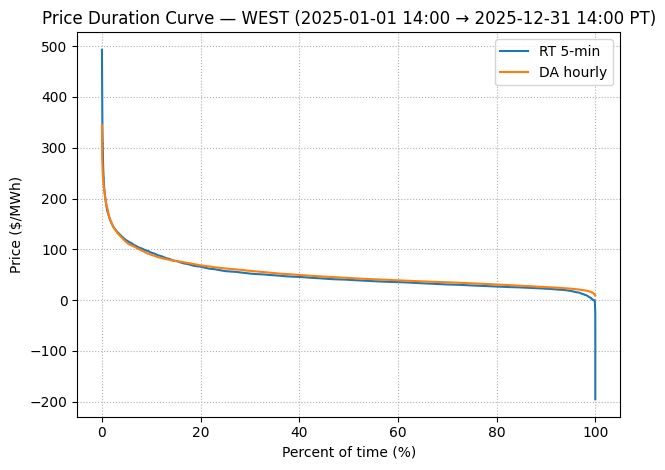

CSV files saved successfully.


In [26]:
from pyomo.environ import *
import pandas as pd
from gridstatusio import GridStatusClient
import numpy as np
import matplotlib.pyplot as plt

client = GridStatusClient(api_key="b66c2e64755c44eb9be56667d66a18f6")
QUERY_LIMIT = 10000

TZ = "America/New_York"

# Define the intended NYISO-local window
pt_start = pd.Timestamp("2025-01-01 14:00", tz=TZ)
pt_end   = pd.Timestamp("2025-12-31 14:00", tz=TZ)

# Convert to UTC for GridStatusClient
utc_start = pt_start.tz_convert("UTC").strftime("%Y-%m-%dT%H:%M:%SZ")
utc_end   = pt_end.tz_convert("UTC").strftime("%Y-%m-%dT%H:%M:%SZ")
df_RT_NYISO = client.get_dataset(
    dataset= "nyiso_lmp_real_time_5_min",
    start=utc_start,
    end=utc_end,
    filter_column = "location",
    filter_value = "WEST",
)

df_DA_NYISO = client.get_dataset(
    dataset= "nyiso_lmp_day_ahead_hourly",
    start=utc_start,
    end=utc_end,
    filter_column = "location",
    filter_value = "WEST",
)

def _sorted_desc(series_like):
    s = pd.Series(series_like).astype(float).dropna()
    return s.sort_values(ascending=False).reset_index(drop=True)

def plot_pdc(df_rt, df_da, price_col="lmp", label_rt="RT 5-min", label_da="DA hourly",
             title_extra="WEST (2025-01-01 14:00 → 2025-12-31 14:00 PT)"):
    # Sort prices high→low
    s_rt = _sorted_desc(df_rt.loc[df_rt[price_col]<= 500,price_col])
    s_da = _sorted_desc(df_da.loc[df_da[price_col]<= 500,price_col])

    # X-axis as % of time covered
    x_rt = np.linspace(0, 100, len(s_rt), endpoint=False)
    x_da = np.linspace(0, 100, len(s_da), endpoint=False)

    # Plot both curves on the same axes
    plt.figure()
    plt.plot(x_rt, s_rt.values, label=label_rt)
    plt.plot(x_da, s_da.values, label=label_da)
    plt.xlabel("Percent of time (%)")
    plt.ylabel("Price ($/MWh)")
    plt.title(f"Price Duration Curve — {title_extra}")
    plt.legend()
    plt.grid(True, linestyle=":")
    plt.tight_layout()
    plt.show()

# Call it (uses your df_RT and df_DA)
plot_pdc(df_RT_NYISO, df_DA_NYISO)

# ---- Save full datasets to CSV ----
df_RT_NYISO.to_csv(
    "df_RT_NYISO_WEST_2025_RT_5min.csv",
    index=False
)

df_DA_NYISO.to_csv(
    "df_DA_NYISO_WEST_2025_DA_hourly.csv",
    index=False
)

print("CSV files saved successfully.")

2026-02-01 23:06:57 - INFO - Fetching Page 1...
2026-02-01 23:06:57 - INFO - GET https://api.gridstatus.io/v1/datasets/nyiso_as_prices_real_time_5_min/query
2026-02-01 23:06:57 - INFO - Params: {'start_time': Timestamp('2025-01-01 19:00:00+0000', tz='UTC'), 'end_time': Timestamp('2025-12-31 19:00:00+0000', tz='UTC'), 'publish_time_start': None, 'publish_time_end': None, 'limit': None, 'page': 1, 'page_size': None, 'resample_frequency': None, 'resample_by': None, 'resample_function': None, 'publish_time': None, 'timezone': None, 'cursor': '', 'filter_column': 'zone', 'filter_value': 'CAPITL', 'filter_operator': '=', 'return_format': 'json', 'json_schema': 'array-of-arrays'}
2026-02-01 23:06:59 - INFO - Done in 1.56 seconds. 
2026-02-01 23:06:59 - INFO - Fetching Page 2...
2026-02-01 23:06:59 - INFO - GET https://api.gridstatus.io/v1/datasets/nyiso_as_prices_real_time_5_min/query
2026-02-01 23:06:59 - INFO - Params: {'start_time': Timestamp('2025-01-01 19:00:00+0000', tz='UTC'), 'end_tim

Columns: ['interval_start_utc', 'interval_end_utc', 'zone', 'spin_reserves_10_min', 'non_spin_reserves_10_min', 'reserves_30_min', 'regulation_capacity']
         interval_start_utc          interval_end_utc    zone  \
0 2025-01-01 19:00:00+00:00 2025-01-01 19:05:00+00:00  CAPITL   
1 2025-01-01 19:04:31+00:00 2025-01-01 19:09:31+00:00  CAPITL   
2 2025-01-01 19:05:00+00:00 2025-01-01 19:10:00+00:00  CAPITL   
3 2025-01-01 19:07:19+00:00 2025-01-01 19:12:19+00:00  CAPITL   
4 2025-01-01 19:10:00+00:00 2025-01-01 19:15:00+00:00  CAPITL   

   spin_reserves_10_min  non_spin_reserves_10_min  reserves_30_min  \
0                   0.0                       0.0              0.0   
1                   0.0                       0.0              0.0   
2                   0.0                       0.0              0.0   
3                   0.0                       0.0              0.0   
4                   0.0                       0.0              0.0   

   regulation_capacity  
0        

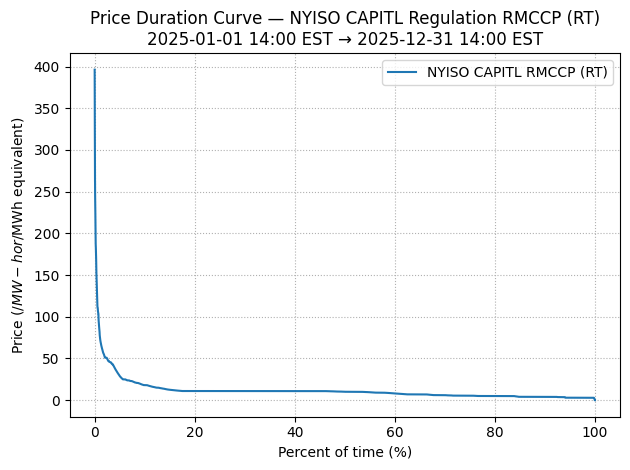

Saved: df_RMCCP_NYISO_CAPITL_2025_RT.csv


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from gridstatusio import GridStatusClient

# -----------------------
# 0) SECURITY: don't hardcode keys in code
# -----------------------
# Better: export GRIDSTATUS_API_KEY in your environment and read it
client = GridStatusClient(api_key="9b41e6e3867c42dbbdccc14af42b5515")

TZ = "America/New_York"

pt_start = pd.Timestamp("2025-01-01 14:00", tz=TZ)
pt_end   = pd.Timestamp("2025-12-31 14:00", tz=TZ)

utc_start = pt_start.tz_convert("UTC").strftime("%Y-%m-%dT%H:%M:%SZ")
utc_end   = pt_end.tz_convert("UTC").strftime("%Y-%m-%dT%H:%M:%SZ")

# -----------------------
# 1) Download PJM RT AS results (Regulation)
# -----------------------
df = client.get_dataset(
    dataset="nyiso_as_prices_real_time_5_min",
    start=utc_start,
    end=utc_end,
    filter_column="zone",
    filter_value="CAPITL",
)

print("Columns:", list(df.columns))
print(df.head())

# -----------------------
# 2) Pick the RMCCP column
# -----------------------
# Option A (recommended): explicitly set it once you confirm the exact column name:
# price_col = "rmccp"

# Option B: try to auto-detect a likely price column:
candidates = [c for c in df.columns if "regulation_capacity" in c.lower()]
if not candidates:
    raise ValueError(
        "Couldn't find an RMCCP column automatically. "
        "Set price_col manually after checking df.columns."
    )
price_col = candidates[0]
print("Using price_col =", price_col)

# -----------------------
# 3) Helper + PDC plot
# -----------------------
def _sorted_desc(series_like):
    s = pd.Series(series_like).astype(float).dropna()
    return s.sort_values(ascending=False).reset_index(drop=True)

def plot_pdc_one(df_in, price_col, label="NYISO CAPITL RMCCP (RT)", clip_max=400,
                 title_extra="NYISO CAPITL Regulation RMCCP (RT)"):
    # clean + optional clip
    s = pd.to_numeric(df_in[price_col], errors="coerce").dropna()
    if clip_max is not None:
        s = s[s <= clip_max]

    s_sorted = _sorted_desc(s)

    x = np.linspace(0, 100, len(s_sorted), endpoint=False)

    plt.figure()
    plt.plot(x, s_sorted.values, label=label)
    plt.xlabel("Percent of time (%)")
    plt.ylabel("Price ($/MW-h or $/MWh equivalent)")
    plt.title(f"Price Duration Curve — {title_extra}\n"
              f"{pt_start.strftime('%Y-%m-%d %H:%M %Z')} → {pt_end.strftime('%Y-%m-%d %H:%M %Z')}")
    plt.legend()
    plt.grid(True, linestyle=":")
    plt.tight_layout()
    plt.show()

plot_pdc_one(df, price_col=price_col)

# -----------------------
# 4) Save to CSV
# -----------------------
out_csv = "df_RMCCP_NYISO_CAPITL_2025_RT.csv"
df.to_csv(out_csv, index=False)
print("Saved:", out_csv)

DA columns: ['interval_start_utc', 'interval_end_utc', 'market', 'location', 'location_type', 'lmp', 'energy', 'congestion', 'loss']
RT columns: ['interval_start_utc', 'interval_end_utc', 'market', 'location', 'location_type', 'lmp', 'energy', 'congestion', 'loss']
[RT] using time col: 'interval_start_utc', price col: 'lmp'
[DA] using time col: 'interval_start_utc', price col: 'lmp'


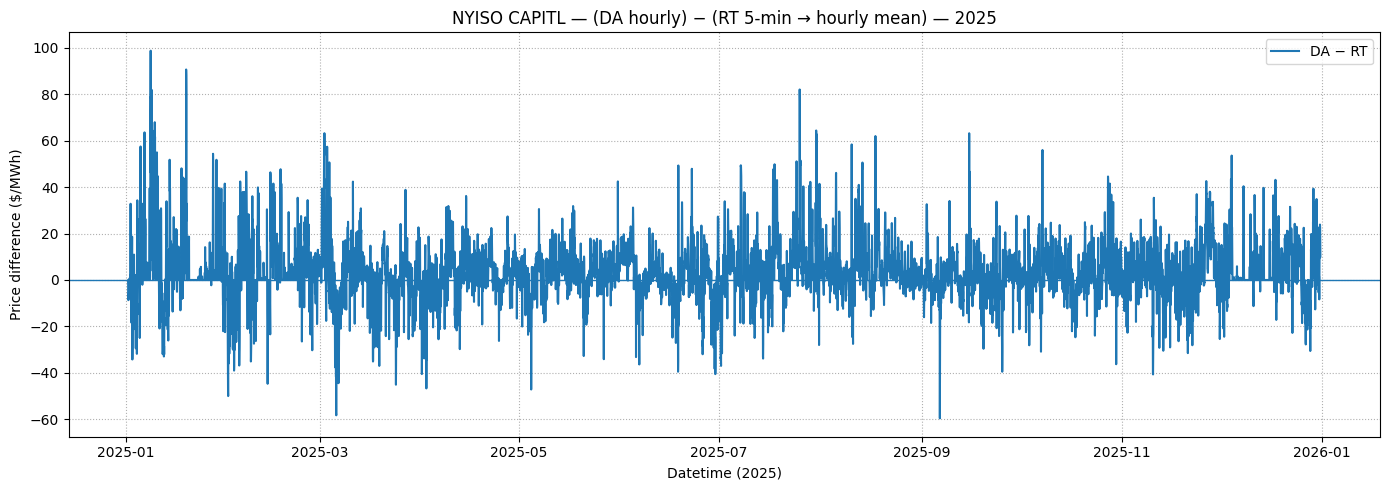

                           DA_hourly  RT_hourly_mean  DA_minus_RT
ts                                                               
2025-01-01 14:00:00-05:00      38.96       39.070667    -0.110667
2025-01-01 15:00:00-05:00      38.79       39.849167    -1.059167
2025-01-01 16:00:00-05:00      41.82       50.513333    -8.693333
2025-01-01 17:00:00-05:00      53.33       60.954167    -7.624167
2025-01-01 18:00:00-05:00      45.86       52.998333    -7.138333


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


def load_table(path: str) -> pd.DataFrame:
    """Load CSV / XLS / XLSX based on extension."""
    p = path.lower()
    if p.endswith(".csv"):
        return pd.read_csv(path)
    if p.endswith((".xls", ".xlsx")):
        return pd.read_excel(path)
    raise ValueError(f"Unsupported file type: {path}")


def plot_da_minus_rt(
    df_rt,
    df_da,
    price_col="lmp",
    clip_low=-500,
    clip_high=500,
    tz_plot="America/New_York",
    rt_hourly_method="mean",   # "mean" | "median" | "last"
    title="NYISO CAPITL — (DA hourly) − (RT 5-min → hourly) — 2025",
    verbose=True,
):
    """
    Plots the time-aligned difference:
        diff(t) = DA_hourly(t) - RT_hourly(t)
    where RT_hourly is RT 5-min resampled to hourly (mean/median/last).
    Prices are clipped to [clip_low, clip_high] BEFORE differencing.
    """

    # --- Find a datetime column robustly ---
    def _get_time_col(df):
        for c in ["interval_start_utc", "interval_start", "time", "timestamp", "datetime"]:
            if c in df.columns:
                return c
        for c in df.columns:
            try:
                if np.issubdtype(df[c].dtype, np.datetime64):
                    return c
            except Exception:
                pass
        raise ValueError("No datetime column found. Columns:\n" + ", ".join(map(str, df.columns)))

    # --- Choose a price column robustly (case-insensitive + fallbacks) ---
    def _pick_price_col(df, preferred):
        if preferred in df.columns:
            return preferred

        lower_map = {c.lower(): c for c in df.columns if isinstance(c, str)}
        if preferred.lower() in lower_map:
            return lower_map[preferred.lower()]

        candidates = [
            "price",
            "lmp",
            "LMP",
            "da_lmp",
            "rt_lmp",
            "market_price",
            "lbmp",
            "mp",
            "value",
        ]
        for c in candidates:
            if c in df.columns:
                return c
            if isinstance(c, str) and c.lower() in lower_map:
                return lower_map[c.lower()]

        numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        for c in numeric_cols:
            if str(c).lower() not in {"year", "month", "day", "hour", "minute"}:
                return c

        raise KeyError(
            f"Could not find a price column. Preferred '{preferred}' not found.\n"
            f"Columns are:\n{list(df.columns)}"
        )

    rt_time_col = _get_time_col(df_rt)
    da_time_col = _get_time_col(df_da)

    rt_price_col = _pick_price_col(df_rt, price_col)
    da_price_col = _pick_price_col(df_da, price_col)

    if verbose:
        print(f"[RT] using time col: '{rt_time_col}', price col: '{rt_price_col}'")
        print(f"[DA] using time col: '{da_time_col}', price col: '{da_price_col}'")

    # --- Prep RT ---
    rt = df_rt[[rt_time_col, rt_price_col]].copy()
    rt[rt_time_col] = pd.to_datetime(rt[rt_time_col], utc=True, errors="coerce")
    rt = rt.dropna(subset=[rt_time_col, rt_price_col]).sort_values(rt_time_col)
    rt["ts"] = rt[rt_time_col].dt.tz_convert(tz_plot)
    rt["price"] = pd.to_numeric(rt[rt_price_col], errors="coerce").clip(lower=clip_low, upper=clip_high)
    rt = rt.dropna(subset=["price"]).set_index("ts")[["price"]]

    # RT 5-min -> hourly
    if rt_hourly_method == "mean":
        rt_h = rt.resample("h").mean()
    elif rt_hourly_method == "median":
        rt_h = rt.resample("h").median()
    elif rt_hourly_method == "last":
        rt_h = rt.resample("h").last()
    else:
        raise ValueError("rt_hourly_method must be one of: mean, median, last")

    rt_h = rt_h.rename(columns={"price": f"RT_hourly_{rt_hourly_method}"})

    # --- Prep DA ---
    da = df_da[[da_time_col, da_price_col]].copy()
    da[da_time_col] = pd.to_datetime(da[da_time_col], utc=True, errors="coerce")
    da = da.dropna(subset=[da_time_col, da_price_col]).sort_values(da_time_col)
    da["ts"] = da[da_time_col].dt.tz_convert(tz_plot)
    da["price"] = pd.to_numeric(da[da_price_col], errors="coerce").clip(lower=clip_low, upper=clip_high)
    da = da.dropna(subset=["price"]).set_index("ts")[["price"]].rename(columns={"price": "DA_hourly"})

    # normalize DA to hourly
    da_h = da.resample("h").mean()

    # --- Align + compute difference ---
    merged = da_h.join(rt_h, how="inner")
    merged["DA_minus_RT"] = merged["DA_hourly"] - merged[f"RT_hourly_{rt_hourly_method}"]

    # --- Plot ---
    plt.figure(figsize=(14, 5))
    plt.plot(merged.index, merged["DA_minus_RT"], label="DA − RT")
    plt.axhline(0, linewidth=1)
    plt.xlabel("Datetime (2025)")
    plt.ylabel("Price difference ($/MWh)")
    plt.title(title)
    plt.grid(True, linestyle=":")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return merged


# =========================
# Load saved NYISO DA/RT files (CSV or Excel) — NO API calls
# =========================

# Option B: absolute paths (raw strings) — uncomment if you prefer
da_path = r"C:\Users\hsofi\EVC\df_DA_NYISO_CAPITL_2025_DA_hourly.csv"
rt_path = r"C:\Users\hsofi\EVC\df_RT_NYISO_CAPITL_2025_RT_5min.csv"

df_DA = load_table(da_path)
df_RT = load_table(rt_path)

print("DA columns:", df_DA.columns.tolist())
print("RT columns:", df_RT.columns.tolist())


# =========================
# Run (NYISO example)
# =========================
diff_df = plot_da_minus_rt(
    df_rt=df_RT,
    df_da=df_DA,
    price_col="lmp",
    clip_low=-100,
    clip_high=100,
    tz_plot="America/New_York",
    rt_hourly_method="mean",
    title="NYISO CAPITL — (DA hourly) − (RT 5-min → hourly mean) — 2025",
    verbose=True,
)

print(diff_df.head())

In [10]:
def dart_extreme_metrics(
    diff_df: pd.DataFrame,
    dart_col="DA_minus_RT",
    threshold=30.0,
):
    """
    Quantify frequency and magnitude of extreme DART spreads.

    Returns a dict of metrics.
    """

    x = diff_df[dart_col].dropna()
    n = len(x)

    if n == 0:
        raise ValueError("No valid DART values found.")

    pos = x[x > threshold]
    neg = x[x < -threshold]
    extreme = x[np.abs(x) > threshold]

    metrics = {
        # ---- counts ----
        "n_hours_total": n,
        "n_hours_DART_gt_30": len(pos),
        "n_hours_DART_lt_-30": len(neg),
        "n_hours_abs_DART_gt_30": len(extreme),

        # ---- frequencies ----
        "pct_hours_DART_gt_30": 100 * len(pos) / n,
        "pct_hours_DART_lt_-30": 100 * len(neg) / n,
        "pct_hours_abs_DART_gt_30": 100 * len(extreme) / n,

        # ---- magnitudes (conditional) ----
        "mean_DART_gt_30": pos.mean() if len(pos) > 0 else np.nan,
        "mean_DART_lt_-30": neg.mean() if len(neg) > 0 else np.nan,
        "max_DART": x.max(),
        "min_DART": x.min(),

        # ---- aggregate severity ----
        "sum_abs_DART_gt_30": np.abs(extreme).sum(),
        "mean_abs_DART_gt_30": np.abs(extreme).mean() if len(extreme) > 0 else np.nan,
    }

    return metrics
dart_metrics = dart_extreme_metrics(
    diff_df,
    dart_col="DA_minus_RT",
    threshold=30,
)

pd.Series(dart_metrics)

n_hours_total                8736.000000
n_hours_DART_gt_30            274.000000
n_hours_DART_lt_-30            82.000000
n_hours_abs_DART_gt_30        356.000000
pct_hours_DART_gt_30            3.136447
pct_hours_DART_lt_-30           0.938645
pct_hours_abs_DART_gt_30        4.075092
mean_DART_gt_30                41.778225
mean_DART_lt_-30              -36.735109
max_DART                       98.772500
min_DART                      -59.608462
sum_abs_DART_gt_30          14459.512467
mean_abs_DART_gt_30            40.616608
dtype: float64

2026-02-14 15:28:10 - INFO - Fetching Page 1...
2026-02-14 15:28:10 - INFO - GET https://api.gridstatus.io/v1/datasets/miso_lmp_real_time_5_min/query
2026-02-14 15:28:10 - INFO - Params: {'start_time': Timestamp('2025-01-01 20:00:00+0000', tz='UTC'), 'end_time': Timestamp('2025-12-31 20:00:00+0000', tz='UTC'), 'publish_time_start': None, 'publish_time_end': None, 'limit': None, 'page': 1, 'page_size': None, 'resample_frequency': None, 'resample_by': None, 'resample_function': None, 'publish_time': None, 'timezone': None, 'cursor': '', 'filter_column': 'location', 'filter_value': 'TEXAS.HUB', 'filter_operator': '=', 'return_format': 'json', 'json_schema': 'array-of-arrays'}
2026-02-14 15:28:41 - INFO - Done in 31.51 seconds. 
2026-02-14 15:28:41 - INFO - Fetching Page 2...
2026-02-14 15:28:41 - INFO - GET https://api.gridstatus.io/v1/datasets/miso_lmp_real_time_5_min/query
2026-02-14 15:28:41 - INFO - Params: {'start_time': Timestamp('2025-01-01 20:00:00+0000', tz='UTC'), 'end_time': Ti

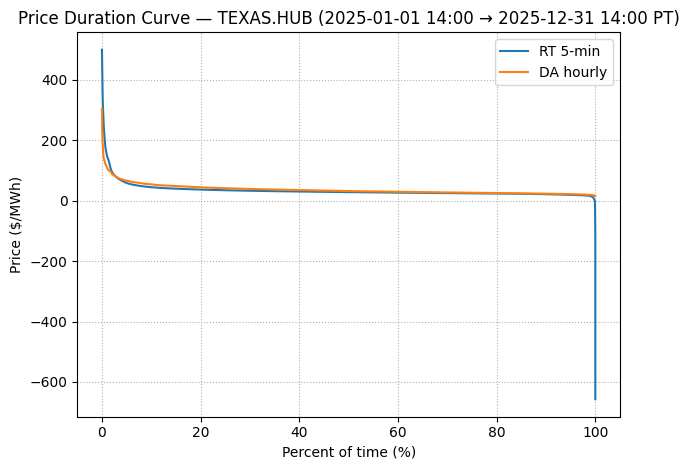

CSV files saved successfully.


In [6]:
from pyomo.environ import *
import pandas as pd
from gridstatusio import GridStatusClient
import numpy as np
import matplotlib.pyplot as plt

client = GridStatusClient(api_key="bf0d830cb6b64c1aa3b0ef08575f8ef1")
QUERY_LIMIT = 10000

TZ = "America/Chicago"

# Define the intended MISO-local window
pt_start = pd.Timestamp("2025-01-01 14:00", tz=TZ)
pt_end   = pd.Timestamp("2025-12-31 14:00", tz=TZ)

# Convert to UTC for GridStatusClient
utc_start = pt_start.tz_convert("UTC").strftime("%Y-%m-%dT%H:%M:%SZ")
utc_end   = pt_end.tz_convert("UTC").strftime("%Y-%m-%dT%H:%M:%SZ")
df_RT_MISO = client.get_dataset(
    dataset= "miso_lmp_real_time_5_min",
    start=utc_start,
    end=utc_end,
    filter_column = "location",
    filter_value = "TEXAS.HUB",
)

df_DA_MISO = client.get_dataset(
    dataset= "miso_lmp_day_ahead_hourly",
    start=utc_start,
    end=utc_end,
    filter_column = "location",
    filter_value = "TEXAS.HUB",
)

def _sorted_desc(series_like):
    s = pd.Series(series_like).astype(float).dropna()
    return s.sort_values(ascending=False).reset_index(drop=True)

def plot_pdc(df_rt, df_da, price_col="lmp", label_rt="RT 5-min", label_da="DA hourly",
             title_extra="TEXAS.HUB (2025-01-01 14:00 → 2025-12-31 14:00 PT)"):
    # Sort prices high→low
    s_rt = _sorted_desc(df_rt.loc[df_rt[price_col]<= 500,price_col])
    s_da = _sorted_desc(df_da.loc[df_da[price_col]<= 500,price_col])

    # X-axis as % of time covered
    x_rt = np.linspace(0, 100, len(s_rt), endpoint=False)
    x_da = np.linspace(0, 100, len(s_da), endpoint=False)

    # Plot both curves on the same axes
    plt.figure()
    plt.plot(x_rt, s_rt.values, label=label_rt)
    plt.plot(x_da, s_da.values, label=label_da)
    plt.xlabel("Percent of time (%)")
    plt.ylabel("Price ($/MWh)")
    plt.title(f"Price Duration Curve — {title_extra}")
    plt.legend()
    plt.grid(True, linestyle=":")
    plt.tight_layout()
    plt.show()

# Call it (uses your df_RT and df_DA)
plot_pdc(df_RT_MISO, df_DA_MISO)
# ---- Save full datasets to CSV ----
df_RT_MISO.to_csv(
    "df_RT_MISO_TEXAS.HUB_2025_RT_5min.csv",
    index=False
)

df_DA_MISO.to_csv(
    "df_DA_MISO_TEXAS.HUB_2025_DA_hourly.csv",
    index=False
)

print("CSV files saved successfully.")

2026-02-02 21:19:17 - INFO - Fetching Page 1...
2026-02-02 21:19:17 - INFO - GET https://api.gridstatus.io/v1/datasets/miso_as_mcp_day_ahead_ex_ante/query
2026-02-02 21:19:17 - INFO - Params: {'start_time': Timestamp('2025-01-01 20:00:00+0000', tz='UTC'), 'end_time': Timestamp('2025-12-31 20:00:00+0000', tz='UTC'), 'publish_time_start': None, 'publish_time_end': None, 'limit': None, 'page': 1, 'page_size': None, 'resample_frequency': None, 'resample_by': None, 'resample_function': None, 'publish_time': None, 'timezone': None, 'cursor': '', 'filter_column': 'zone', 'filter_value': 'Zone 8', 'filter_operator': '=', 'return_format': 'json', 'json_schema': 'array-of-arrays'}
2026-02-02 21:19:18 - INFO - Done in 1.27 seconds. 
2026-02-02 21:19:18 - INFO - Total number of rows: 8736


Columns: ['interval_start_utc', 'interval_end_utc', 'zone', 'ramp_down', 'ramp_up', 'regulation', 'str', 'spin', 'supplemental']
         interval_start_utc          interval_end_utc    zone  ramp_down  \
0 2025-01-01 20:00:00+00:00 2025-01-01 21:00:00+00:00  Zone 8        0.0   
1 2025-01-01 21:00:00+00:00 2025-01-01 22:00:00+00:00  Zone 8        0.0   
2 2025-01-01 22:00:00+00:00 2025-01-01 23:00:00+00:00  Zone 8        0.0   
3 2025-01-01 23:00:00+00:00 2025-01-02 00:00:00+00:00  Zone 8        0.0   
4 2025-01-02 00:00:00+00:00 2025-01-02 01:00:00+00:00  Zone 8        0.0   

   ramp_up  regulation   str   spin  supplemental  
0      0.0        7.77  0.00   1.55          0.18  
1      4.0       12.56  0.00   4.00          0.18  
2      5.0       20.00  0.00   5.78          0.20  
3      9.8       24.89  0.18  14.03          0.20  
4      5.0       20.00  0.17   7.57          0.20  
Using price_col = regulation


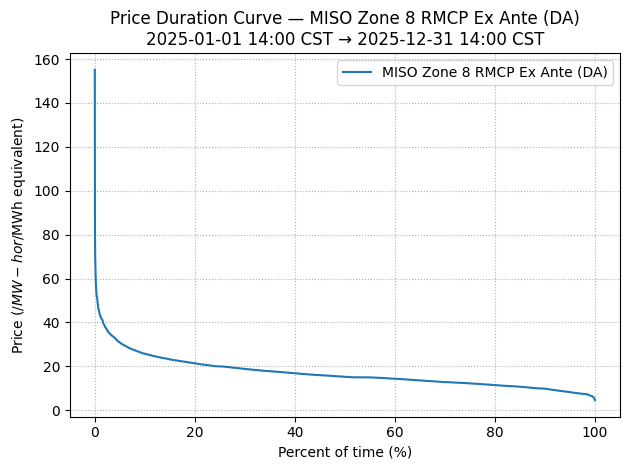

Saved: df_RMCP_MISO_Zone 8_2025_DA_EXante.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from gridstatusio import GridStatusClient

# -----------------------
# 0) SECURITY: don't hardcode keys in code
# -----------------------
# Better: export GRIDSTATUS_API_KEY in your environment and read it
client = GridStatusClient(api_key="76e0e2ac84aa47d69a6f019c1abf044b")

TZ = "America/Chicago"

pt_start = pd.Timestamp("2025-01-01 14:00", tz=TZ)
pt_end   = pd.Timestamp("2025-12-31 14:00", tz=TZ)

utc_start = pt_start.tz_convert("UTC").strftime("%Y-%m-%dT%H:%M:%SZ")
utc_end   = pt_end.tz_convert("UTC").strftime("%Y-%m-%dT%H:%M:%SZ")

# -----------------------
# 1) Download PJM RT AS results (Regulation)
# -----------------------
df = client.get_dataset(
    dataset="miso_as_mcp_day_ahead_ex_ante",
    start=utc_start,
    end=utc_end,
    filter_column="zone",
    filter_value="Zone 8",
)

print("Columns:", list(df.columns))
print(df.head())

# -----------------------
# 2) Pick the RMCCP column
# -----------------------
# Option A (recommended): explicitly set it once you confirm the exact column name:
# price_col = "rmccp"

# Option B: try to auto-detect a likely price column:
candidates = [c for c in df.columns if "regulation" in c.lower()]
if not candidates:
    raise ValueError(
        "Couldn't find an RMCCP column automatically. "
        "Set price_col manually after checking df.columns."
    )
price_col = candidates[0]
print("Using price_col =", price_col)

# -----------------------
# 3) Helper + PDC plot
# -----------------------
def _sorted_desc(series_like):
    s = pd.Series(series_like).astype(float).dropna()
    return s.sort_values(ascending=False).reset_index(drop=True)

def plot_pdc_one(df_in, price_col, label="MISO Zone 8 RMCP Ex Ante (DA)", clip_max=1000,
                 title_extra="MISO Zone 8 RMCP Ex Ante (DA)"):
    # clean + optional clip
    s = pd.to_numeric(df_in[price_col], errors="coerce").dropna()
    if clip_max is not None:
        s = s[s <= clip_max]

    s_sorted = _sorted_desc(s)

    x = np.linspace(0, 100, len(s_sorted), endpoint=False)

    plt.figure()
    plt.plot(x, s_sorted.values, label=label)
    plt.xlabel("Percent of time (%)")
    plt.ylabel("Price ($/MW-h or $/MWh equivalent)")
    plt.title(f"Price Duration Curve — {title_extra}\n"
              f"{pt_start.strftime('%Y-%m-%d %H:%M %Z')} → {pt_end.strftime('%Y-%m-%d %H:%M %Z')}")
    plt.legend()
    plt.grid(True, linestyle=":")
    plt.tight_layout()
    plt.show()

plot_pdc_one(df, price_col=price_col)

# -----------------------
# 4) Save to CSV
# -----------------------
out_csv = "df_RMCP_MISO_Zone 8_2025_DA_EXante.csv"
df.to_csv(out_csv, index=False)
print("Saved:", out_csv)

DA columns: ['interval_start_utc', 'interval_end_utc', 'market', 'location', 'location_type', 'lmp', 'energy', 'congestion', 'loss']
RT columns: ['interval_start_utc', 'interval_end_utc', 'market', 'location', 'location_type', 'lmp', 'energy', 'congestion', 'loss']
[RT] using time col: 'interval_start_utc', price col: 'lmp'
[DA] using time col: 'interval_start_utc', price col: 'lmp'


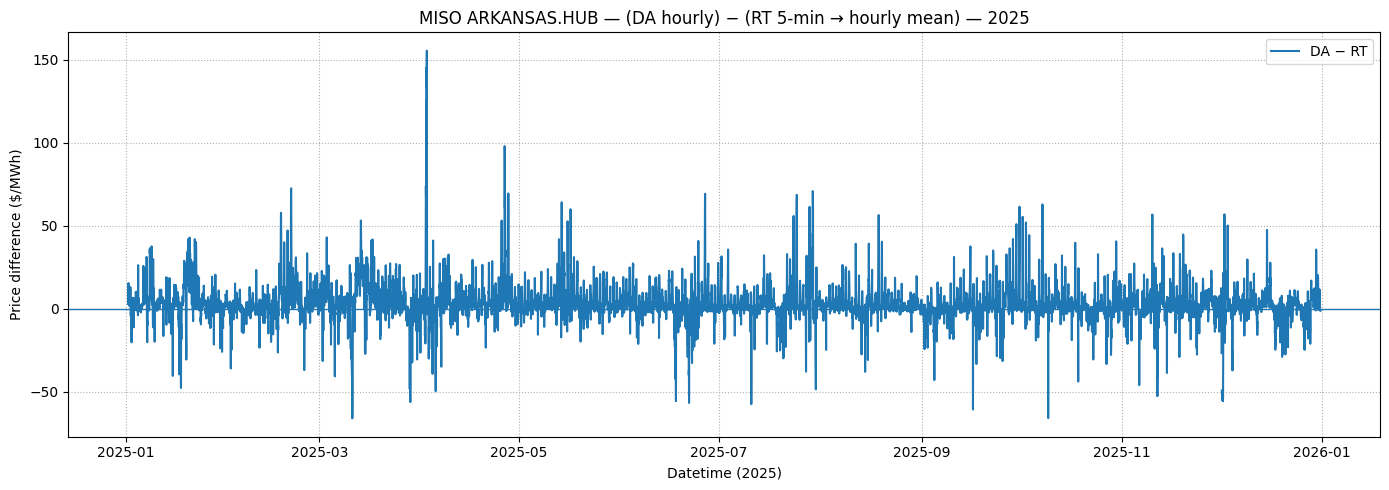

                           DA_hourly  RT_hourly_mean  DA_minus_RT
ts                                                               
2025-01-01 14:00:00-06:00      23.59       20.570000     3.020000
2025-01-01 15:00:00-06:00      27.91       21.679167     6.230833
2025-01-01 16:00:00-06:00      31.81       29.011667     2.798333
2025-01-01 17:00:00-06:00      44.46       28.975000    15.485000
2025-01-01 18:00:00-06:00      36.37       29.060833     7.309167


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


def load_table(path: str) -> pd.DataFrame:
    """Load CSV / XLS / XLSX based on extension."""
    p = path.lower()
    if p.endswith(".csv"):
        return pd.read_csv(path)
    if p.endswith((".xls", ".xlsx")):
        return pd.read_excel(path)
    raise ValueError(f"Unsupported file type: {path}")


def plot_da_minus_rt(
    df_rt,
    df_da,
    price_col="lmp",
    clip_low=-500,
    clip_high=500,
    tz_plot="America/Chicago",
    rt_hourly_method="mean",   # "mean" | "median" | "last"
    title="MISO ARKANSAS.HUB — (DA hourly) − (RT 5-min → hourly) — 2025",
    verbose=True,
):
    """
    Plots the time-aligned difference:
        diff(t) = DA_hourly(t) - RT_hourly(t)
    where RT_hourly is RT 5-min resampled to hourly (mean/median/last).
    Prices are clipped to [clip_low, clip_high] BEFORE differencing.
    """

    # --- Find a datetime column robustly (GridStatus datasets vary) ---
    def _get_time_col(df):
        for c in ["interval_start_utc", "interval_start", "time", "timestamp", "datetime"]:
            if c in df.columns:
                return c
        for c in df.columns:
            try:
                if np.issubdtype(df[c].dtype, np.datetime64):
                    return c
            except Exception:
                pass
        raise ValueError("No datetime column found. Columns:\n" + ", ".join(map(str, df.columns)))

    # --- Choose a price column robustly (case-insensitive + fallbacks) ---
    def _pick_price_col(df, preferred):
        if preferred in df.columns:
            return preferred

        lower_map = {c.lower(): c for c in df.columns if isinstance(c, str)}
        if preferred.lower() in lower_map:
            return lower_map[preferred.lower()]

        candidates = [
            "price",
            "lmp",
            "LMP",
            "da_lmp",
            "rt_lmp",
            "market_price",
            "settlement_point_price",
            "settlement_point_price_dollar_per_mwh",
            "lbmp",
            "mp",
            "value",
        ]
        for c in candidates:
            if c in df.columns:
                return c
            if isinstance(c, str) and c.lower() in lower_map:
                return lower_map[c.lower()]

        numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        for c in numeric_cols:
            if str(c).lower() not in {"year", "month", "day", "hour", "minute"}:
                return c

        raise KeyError(
            f"Could not find a price column. Preferred '{preferred}' not found.\n"
            f"Columns are:\n{list(df.columns)}"
        )

    rt_time_col = _get_time_col(df_rt)
    da_time_col = _get_time_col(df_da)

    rt_price_col = _pick_price_col(df_rt, price_col)
    da_price_col = _pick_price_col(df_da, price_col)

    if verbose:
        print(f"[RT] using time col: '{rt_time_col}', price col: '{rt_price_col}'")
        print(f"[DA] using time col: '{da_time_col}', price col: '{da_price_col}'")

    # --- Prep RT ---
    rt = df_rt[[rt_time_col, rt_price_col]].copy()
    rt[rt_time_col] = pd.to_datetime(rt[rt_time_col], utc=True, errors="coerce")
    rt = rt.dropna(subset=[rt_time_col, rt_price_col]).sort_values(rt_time_col)
    rt["ts"] = rt[rt_time_col].dt.tz_convert(tz_plot)
    rt["price"] = pd.to_numeric(rt[rt_price_col], errors="coerce").clip(lower=clip_low, upper=clip_high)
    rt = rt.dropna(subset=["price"]).set_index("ts")[["price"]]

    # Resample RT 5-min -> hourly
    if rt_hourly_method == "mean":
        rt_h = rt.resample("h").mean()
    elif rt_hourly_method == "median":
        rt_h = rt.resample("h").median()
    elif rt_hourly_method == "last":
        rt_h = rt.resample("h").last()
    else:
        raise ValueError("rt_hourly_method must be one of: mean, median, last")

    rt_h = rt_h.rename(columns={"price": f"RT_hourly_{rt_hourly_method}"})

    # --- Prep DA ---
    da = df_da[[da_time_col, da_price_col]].copy()
    da[da_time_col] = pd.to_datetime(da[da_time_col], utc=True, errors="coerce")
    da = da.dropna(subset=[da_time_col, da_price_col]).sort_values(da_time_col)
    da["ts"] = da[da_time_col].dt.tz_convert(tz_plot)
    da["price"] = pd.to_numeric(da[da_price_col], errors="coerce").clip(lower=clip_low, upper=clip_high)
    da = da.dropna(subset=["price"]).set_index("ts")[["price"]].rename(columns={"price": "DA_hourly"})

    # Normalize DA to hourly
    da_h = da.resample("h").mean()

    # --- Align + compute difference ---
    merged = da_h.join(rt_h, how="inner")
    merged["DA_minus_RT"] = merged["DA_hourly"] - merged[f"RT_hourly_{rt_hourly_method}"]

    # --- Plot ---
    plt.figure(figsize=(14, 5))
    plt.plot(merged.index, merged["DA_minus_RT"], label="DA − RT")
    plt.axhline(0, linewidth=1)
    plt.xlabel("Datetime (2025)")
    plt.ylabel("Price difference ($/MWh)")
    plt.title(title)
    plt.grid(True, linestyle=":")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return merged


# =========================
# Load saved MISO DA/RT files (CSV or Excel) — NO API calls
# =========================

# Option B: absolute paths (raw strings) — uncomment if you prefer
da_path = r"C:\Users\hsofi\EVC\df_DA_MISO_ARKANSAS.HUB_2025_DA_hourly.csv"
rt_path = r"C:\Users\hsofi\EVC\df_RT_MISO_ARKANSAS.HUB_2025_RT_5min.csv"

df_DA = load_table(da_path)
df_RT = load_table(rt_path)

print("DA columns:", df_DA.columns.tolist())
print("RT columns:", df_RT.columns.tolist())


# =========================
# Run (MISO example)
# =========================
diff_df = plot_da_minus_rt(
    df_rt=df_RT,
    df_da=df_DA,
    price_col="lmp",
    clip_low=-100,
    clip_high=100,
    tz_plot="America/Chicago",   # MISO local is typically Central
    rt_hourly_method="mean",
    title="MISO ARKANSAS.HUB — (DA hourly) − (RT 5-min → hourly mean) — 2025",
    verbose=True,
)

print(diff_df.head())


In [12]:
def dart_extreme_metrics(
    diff_df: pd.DataFrame,
    dart_col="DA_minus_RT",
    threshold=30.0,
):
    """
    Quantify frequency and magnitude of extreme DART spreads.

    Returns a dict of metrics.
    """

    x = diff_df[dart_col].dropna()
    n = len(x)

    if n == 0:
        raise ValueError("No valid DART values found.")

    pos = x[x > threshold]
    neg = x[x < -threshold]
    extreme = x[np.abs(x) > threshold]

    metrics = {
        # ---- counts ----
        "n_hours_total": n,
        "n_hours_DART_gt_30": len(pos),
        "n_hours_DART_lt_-30": len(neg),
        "n_hours_abs_DART_gt_30": len(extreme),

        # ---- frequencies ----
        "pct_hours_DART_gt_30": 100 * len(pos) / n,
        "pct_hours_DART_lt_-30": 100 * len(neg) / n,
        "pct_hours_abs_DART_gt_30": 100 * len(extreme) / n,

        # ---- magnitudes (conditional) ----
        "mean_DART_gt_30": pos.mean() if len(pos) > 0 else np.nan,
        "mean_DART_lt_-30": neg.mean() if len(neg) > 0 else np.nan,
        "max_DART": x.max(),
        "min_DART": x.min(),

        # ---- aggregate severity ----
        "sum_abs_DART_gt_30": np.abs(extreme).sum(),
        "mean_abs_DART_gt_30": np.abs(extreme).mean() if len(extreme) > 0 else np.nan,
    }

    return metrics
dart_metrics = dart_extreme_metrics(
    diff_df,
    dart_col="DA_minus_RT",
    threshold=30,
)

pd.Series(dart_metrics)

n_hours_total                8720.000000
n_hours_DART_gt_30            176.000000
n_hours_DART_lt_-30            62.000000
n_hours_abs_DART_gt_30        238.000000
pct_hours_DART_gt_30            2.018349
pct_hours_DART_lt_-30           0.711009
pct_hours_abs_DART_gt_30        2.729358
mean_DART_gt_30                46.009882
mean_DART_lt_-30              -43.859977
max_DART                      155.510000
min_DART                      -66.036667
sum_abs_DART_gt_30          10817.057848
mean_abs_DART_gt_30            45.449823
dtype: float64

2026-02-14 16:15:41 - INFO - Fetching Page 1...
2026-02-14 16:15:41 - INFO - GET https://api.gridstatus.io/v1/datasets/isone_lmp_real_time_5_min/query
2026-02-14 16:15:41 - INFO - Params: {'start_time': Timestamp('2025-01-01 19:00:00+0000', tz='UTC'), 'end_time': Timestamp('2025-12-31 19:00:00+0000', tz='UTC'), 'publish_time_start': None, 'publish_time_end': None, 'limit': None, 'page': 1, 'page_size': None, 'resample_frequency': None, 'resample_by': None, 'resample_function': None, 'publish_time': None, 'timezone': None, 'cursor': '', 'filter_column': 'location', 'filter_value': '.Z.VERMONT', 'filter_operator': '=', 'return_format': 'json', 'json_schema': 'array-of-arrays'}
2026-02-14 16:15:42 - INFO - Done in 1.62 seconds. 
2026-02-14 16:15:42 - INFO - Fetching Page 2...
2026-02-14 16:15:42 - INFO - GET https://api.gridstatus.io/v1/datasets/isone_lmp_real_time_5_min/query
2026-02-14 16:15:42 - INFO - Params: {'start_time': Timestamp('2025-01-01 19:00:00+0000', tz='UTC'), 'end_time': 

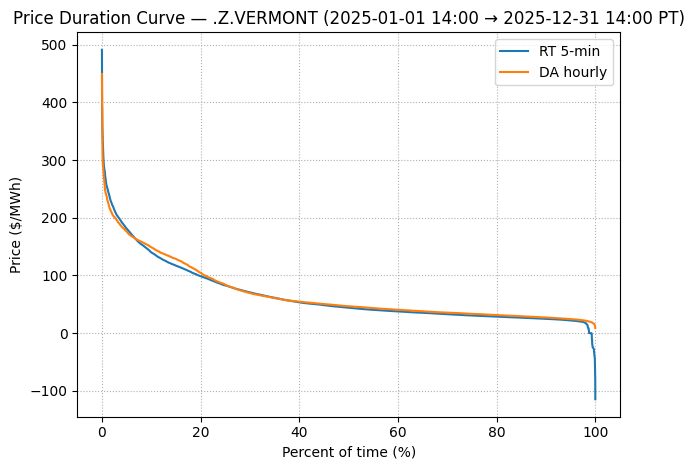

CSV files saved successfully.


In [15]:
from pyomo.environ import *
import pandas as pd
from gridstatusio import GridStatusClient
import numpy as np
import matplotlib.pyplot as plt

client = GridStatusClient(api_key="049071f2fbf54cf3b90ebe62aea819ee")
QUERY_LIMIT = 10000

TZ = "America/New_York"

# Define the intended ISONE-local window
pt_start = pd.Timestamp("2025-01-01 14:00", tz=TZ)
pt_end   = pd.Timestamp("2025-12-31 14:00", tz=TZ)

# Convert to UTC for GridStatusClient
utc_start = pt_start.tz_convert("UTC").strftime("%Y-%m-%dT%H:%M:%SZ")
utc_end   = pt_end.tz_convert("UTC").strftime("%Y-%m-%dT%H:%M:%SZ")
df_RT_ISONE = client.get_dataset(
    dataset= "isone_lmp_real_time_5_min",
    start=utc_start,
    end=utc_end,
    filter_column = "location",
    filter_value = ".Z.VERMONT",
)

df_DA_ISONE = client.get_dataset(
    dataset= "isone_lmp_day_ahead_hourly",
    start=utc_start,
    end=utc_end,
    filter_column = "location",
    filter_value = ".Z.VERMONT",
)

def _sorted_desc(series_like):
    s = pd.Series(series_like).astype(float).dropna()
    return s.sort_values(ascending=False).reset_index(drop=True)

def plot_pdc(df_rt, df_da, price_col="lmp", label_rt="RT 5-min", label_da="DA hourly",
             title_extra=".Z.VERMONT (2025-01-01 14:00 → 2025-12-31 14:00 PT)"):
    # Sort prices high→low
    s_rt = _sorted_desc(df_rt.loc[df_rt[price_col]<= 500,price_col])
    s_da = _sorted_desc(df_da.loc[df_da[price_col]<= 500,price_col])

    # X-axis as % of time covered
    x_rt = np.linspace(0, 100, len(s_rt), endpoint=False)
    x_da = np.linspace(0, 100, len(s_da), endpoint=False)

    # Plot both curves on the same axes
    plt.figure()
    plt.plot(x_rt, s_rt.values, label=label_rt)
    plt.plot(x_da, s_da.values, label=label_da)
    plt.xlabel("Percent of time (%)")
    plt.ylabel("Price ($/MWh)")
    plt.title(f"Price Duration Curve — {title_extra}")
    plt.legend()
    plt.grid(True, linestyle=":")
    plt.tight_layout()
    plt.show()

# Call it (uses your df_RT and df_DA)
plot_pdc(df_RT_ISONE, df_DA_ISONE)

df_RT_ISONE.to_csv(
    "df_RT_ISONE_Z.VERMONT_2025_RT_5min.csv",
    index=False
)

df_DA_ISONE.to_csv(
    "df_DA_ISONE_Z.VERMONT_2025_DA_hourly.csv",
    index=False
)

print("CSV files saved successfully.")

2026-02-01 23:08:44 - INFO - Fetching Page 1...
2026-02-01 23:08:44 - INFO - GET https://api.gridstatus.io/v1/datasets/isone_regulation_clearing_prices_real_time_5_min/query
2026-02-01 23:08:44 - INFO - Params: {'start_time': Timestamp('2025-01-01 19:00:00+0000', tz='UTC'), 'end_time': Timestamp('2025-12-31 19:00:00+0000', tz='UTC'), 'publish_time_start': None, 'publish_time_end': None, 'limit': None, 'page': 1, 'page_size': None, 'resample_frequency': None, 'resample_by': None, 'resample_function': None, 'publish_time': None, 'timezone': None, 'cursor': '', 'filter_column': None, 'filter_value': None, 'filter_operator': '=', 'return_format': 'json', 'json_schema': 'array-of-arrays'}
2026-02-01 23:08:46 - INFO - Done in 1.79 seconds. 
2026-02-01 23:08:46 - INFO - Fetching Page 2...
2026-02-01 23:08:46 - INFO - GET https://api.gridstatus.io/v1/datasets/isone_regulation_clearing_prices_real_time_5_min/query
2026-02-01 23:08:46 - INFO - Params: {'start_time': Timestamp('2025-01-01 19:00:0

Columns: ['interval_start_utc', 'interval_end_utc', 'reg_service_clearing_price', 'reg_capacity_clearing_price']
         interval_start_utc          interval_end_utc  \
0 2025-01-01 19:00:00+00:00 2025-01-01 19:05:00+00:00   
1 2025-01-01 19:05:00+00:00 2025-01-01 19:10:00+00:00   
2 2025-01-01 19:10:00+00:00 2025-01-01 19:15:00+00:00   
3 2025-01-01 19:15:00+00:00 2025-01-01 19:20:00+00:00   
4 2025-01-01 19:20:00+00:00 2025-01-01 19:25:00+00:00   

   reg_service_clearing_price  reg_capacity_clearing_price  
0                         0.0                          0.0  
1                         0.0                          0.0  
2                         0.0                          0.0  
3                         0.0                          0.0  
4                         0.0                          0.0  
Using price_col = reg_capacity_clearing_price


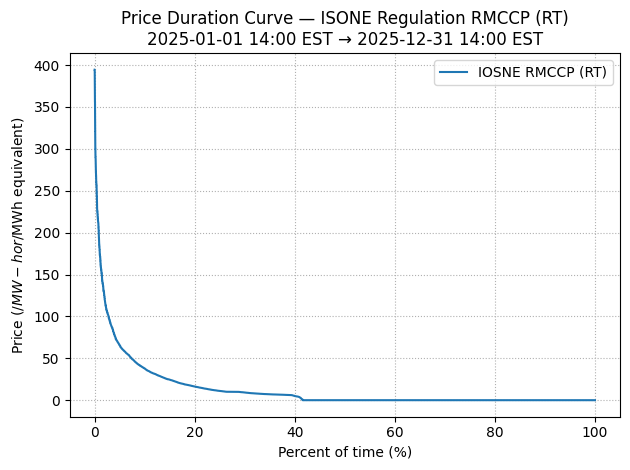

Saved: df_RMCCP_ISONE_2025_RT.csv


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from gridstatusio import GridStatusClient

# -----------------------
# 0) SECURITY: don't hardcode keys in code
# -----------------------
# Better: export GRIDSTATUS_API_KEY in your environment and read it
client = GridStatusClient(api_key="9b41e6e3867c42dbbdccc14af42b5515")

TZ = "America/New_York"

pt_start = pd.Timestamp("2025-01-01 14:00", tz=TZ)
pt_end   = pd.Timestamp("2025-12-31 14:00", tz=TZ)

utc_start = pt_start.tz_convert("UTC").strftime("%Y-%m-%dT%H:%M:%SZ")
utc_end   = pt_end.tz_convert("UTC").strftime("%Y-%m-%dT%H:%M:%SZ")

# -----------------------
# 1) Download PJM RT AS results (Regulation)
# -----------------------
df = client.get_dataset(
    dataset="isone_regulation_clearing_prices_real_time_5_min",
    start=utc_start,
    end=utc_end,
)

print("Columns:", list(df.columns))
print(df.head())

# -----------------------
# 2) Pick the RMCCP column
# -----------------------
# Option A (recommended): explicitly set it once you confirm the exact column name:
# price_col = "rmccp"

# Option B: try to auto-detect a likely price column:
candidates = [c for c in df.columns if "reg_capacity_clearing_price" in c.lower()]
if not candidates:
    raise ValueError(
        "Couldn't find an RMCCP column automatically. "
        "Set price_col manually after checking df.columns."
    )
price_col = candidates[0]
print("Using price_col =", price_col)

# -----------------------
# 3) Helper + PDC plot
# -----------------------
def _sorted_desc(series_like):
    s = pd.Series(series_like).astype(float).dropna()
    return s.sort_values(ascending=False).reset_index(drop=True)

def plot_pdc_one(df_in, price_col, label="IOSNE RMCCP (RT)", clip_max=400,
                 title_extra="ISONE Regulation RMCCP (RT)"):
    # clean + optional clip
    s = pd.to_numeric(df_in[price_col], errors="coerce").dropna()
    if clip_max is not None:
        s = s[s <= clip_max]

    s_sorted = _sorted_desc(s)

    x = np.linspace(0, 100, len(s_sorted), endpoint=False)

    plt.figure()
    plt.plot(x, s_sorted.values, label=label)
    plt.xlabel("Percent of time (%)")
    plt.ylabel("Price ($/MW-h or $/MWh equivalent)")
    plt.title(f"Price Duration Curve — {title_extra}\n"
              f"{pt_start.strftime('%Y-%m-%d %H:%M %Z')} → {pt_end.strftime('%Y-%m-%d %H:%M %Z')}")
    plt.legend()
    plt.grid(True, linestyle=":")
    plt.tight_layout()
    plt.show()

plot_pdc_one(df, price_col=price_col)

# -----------------------
# 4) Save to CSV
# -----------------------
out_csv = "df_RMCCP_ISONE_2025_RT.csv"
df.to_csv(out_csv, index=False)
print("Saved:", out_csv)

C:\Users\hsofi\AppData\Local\Temp\ipykernel_23412\400553484.py:10: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(path)


DA columns: ['interval_start_utc', 'interval_end_utc', 'market', 'location', 'location_type', 'lmp', 'energy', 'congestion', 'loss']
RT columns: ['interval_start_utc', 'interval_end_utc', 'market', 'location', 'location_type', 'lmp', 'energy', 'congestion', 'loss']
[RT] using time col: 'interval_start_utc', price col: 'lmp'
[DA] using time col: 'interval_start_utc', price col: 'lmp'


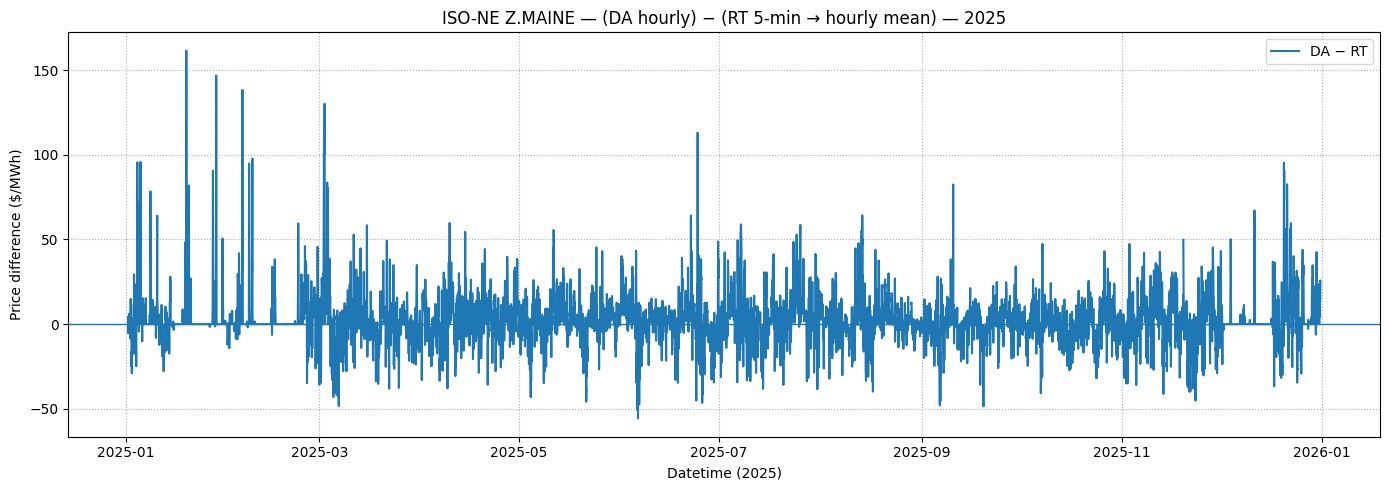

                           DA_hourly  RT_hourly_mean  DA_minus_RT
ts                                                               
2025-01-01 14:00:00-05:00      37.72       39.635000    -1.915000
2025-01-01 15:00:00-05:00      37.54       42.868333    -5.328333
2025-01-01 16:00:00-05:00      48.84       47.129167     1.710833
2025-01-01 17:00:00-05:00      54.43       53.915000     0.515000
2025-01-01 18:00:00-05:00      50.16       45.506667     4.653333


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


def load_table(path: str) -> pd.DataFrame:
    """Load CSV / XLS / XLSX based on extension."""
    p = path.lower()
    if p.endswith(".csv"):
        return pd.read_csv(path)
    if p.endswith((".xls", ".xlsx")):
        return pd.read_excel(path)
    raise ValueError(f"Unsupported file type: {path}")


def plot_da_minus_rt(
    df_rt,
    df_da,
    price_col="lmp",
    clip_low=-500,
    clip_high=500,
    tz_plot="America/New_York",
    rt_hourly_method="mean",   # "mean" | "median" | "last"
    title="ISO-NE Z.MAINE — (DA hourly) − (RT 5-min → hourly) — 2025",
    verbose=True,
):
    """
    Plots the time-aligned difference:
        diff(t) = DA_hourly(t) - RT_hourly(t)
    where RT_hourly is RT 5-min resampled to hourly (mean/median/last).
    Prices are clipped to [clip_low, clip_high] BEFORE differencing.
    """

    # --- Find a datetime column robustly (GridStatus datasets vary) ---
    def _get_time_col(df):
        for c in ["interval_start_utc", "interval_start", "time", "timestamp", "datetime"]:
            if c in df.columns:
                return c
        for c in df.columns:
            try:
                if np.issubdtype(df[c].dtype, np.datetime64):
                    return c
            except Exception:
                pass
        raise ValueError("No datetime column found. Columns:\n" + ", ".join(map(str, df.columns)))

    # --- Choose a price column robustly (case-insensitive + fallbacks) ---
    def _pick_price_col(df, preferred):
        if preferred in df.columns:
            return preferred

        lower_map = {c.lower(): c for c in df.columns if isinstance(c, str)}
        if preferred.lower() in lower_map:
            return lower_map[preferred.lower()]

        candidates = [
            "price",
            "lmp",
            "LMP",
            "da_lmp",
            "rt_lmp",
            "market_price",
            "settlement_point_price",
            "settlement_point_price_dollar_per_mwh",
            "lbmp",
            "mp",
            "value",
        ]
        for c in candidates:
            if c in df.columns:
                return c
            if isinstance(c, str) and c.lower() in lower_map:
                return lower_map[c.lower()]

        numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        for c in numeric_cols:
            if str(c).lower() not in {"year", "month", "day", "hour", "minute"}:
                return c

        raise KeyError(
            f"Could not find a price column. Preferred '{preferred}' not found.\n"
            f"Columns are:\n{list(df.columns)}"
        )

    rt_time_col = _get_time_col(df_rt)
    da_time_col = _get_time_col(df_da)

    rt_price_col = _pick_price_col(df_rt, price_col)
    da_price_col = _pick_price_col(df_da, price_col)

    if verbose:
        print(f"[RT] using time col: '{rt_time_col}', price col: '{rt_price_col}'")
        print(f"[DA] using time col: '{da_time_col}', price col: '{da_price_col}'")

    # --- Prep RT ---
    rt = df_rt[[rt_time_col, rt_price_col]].copy()
    rt[rt_time_col] = pd.to_datetime(rt[rt_time_col], utc=True, errors="coerce")
    rt = rt.dropna(subset=[rt_time_col, rt_price_col]).sort_values(rt_time_col)
    rt["ts"] = rt[rt_time_col].dt.tz_convert(tz_plot)
    rt["price"] = pd.to_numeric(rt[rt_price_col], errors="coerce").clip(lower=clip_low, upper=clip_high)
    rt = rt.dropna(subset=["price"]).set_index("ts")[["price"]]

    # Resample RT 5-min -> hourly
    if rt_hourly_method == "mean":
        rt_h = rt.resample("h").mean()
    elif rt_hourly_method == "median":
        rt_h = rt.resample("h").median()
    elif rt_hourly_method == "last":
        rt_h = rt.resample("h").last()
    else:
        raise ValueError("rt_hourly_method must be one of: mean, median, last")

    rt_h = rt_h.rename(columns={"price": f"RT_hourly_{rt_hourly_method}"})

    # --- Prep DA ---
    da = df_da[[da_time_col, da_price_col]].copy()
    da[da_time_col] = pd.to_datetime(da[da_time_col], utc=True, errors="coerce")
    da = da.dropna(subset=[da_time_col, da_price_col]).sort_values(da_time_col)
    da["ts"] = da[da_time_col].dt.tz_convert(tz_plot)
    da["price"] = pd.to_numeric(da[da_price_col], errors="coerce").clip(lower=clip_low, upper=clip_high)
    da = da.dropna(subset=["price"]).set_index("ts")[["price"]].rename(columns={"price": "DA_hourly"})

    # Normalize DA to hourly
    da_h = da.resample("h").mean()

    # --- Align + compute difference ---
    merged = da_h.join(rt_h, how="inner")
    merged["DA_minus_RT"] = merged["DA_hourly"] - merged[f"RT_hourly_{rt_hourly_method}"]

    # --- Plot ---
    plt.figure(figsize=(14, 5))
    plt.plot(merged.index, merged["DA_minus_RT"], label="DA − RT")
    plt.axhline(0, linewidth=1)
    plt.xlabel("Datetime (2025)")
    plt.ylabel("Price difference ($/MWh)")
    plt.title(title)
    plt.grid(True, linestyle=":")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return merged


# =========================
# Load saved ISO-NE DA/RT files (CSV or Excel) — NO API calls
# =========================

# Option B: absolute paths (raw strings) — uncomment if you prefer
da_path = r"C:\Users\hsofi\EVC\df_DA_ISONE_Z.MAINE_2025_DA_hourly.csv"
rt_path = r"C:\Users\hsofi\EVC\df_RT_ISONE_Z.MAINE_2025_RT_5min.csv"

df_DA = load_table(da_path)
df_RT = load_table(rt_path)

print("DA columns:", df_DA.columns.tolist())
print("RT columns:", df_RT.columns.tolist())


# =========================
# Run (ISO-NE example)
# =========================
diff_df = plot_da_minus_rt(
    df_rt=df_RT,
    df_da=df_DA,
    price_col="lmp",          # OK to leave; function will auto-detect if missing
    clip_low=-100,
    clip_high=100,
    tz_plot="America/New_York",
    rt_hourly_method="mean",
    title="ISO-NE Z.MAINE — (DA hourly) − (RT 5-min → hourly mean) — 2025",
    verbose=True,
)

print(diff_df.head())


In [14]:
def dart_extreme_metrics(
    diff_df: pd.DataFrame,
    dart_col="DA_minus_RT",
    threshold=30.0,
):
    """
    Quantify frequency and magnitude of extreme DART spreads.

    Returns a dict of metrics.
    """

    x = diff_df[dart_col].dropna()
    n = len(x)

    if n == 0:
        raise ValueError("No valid DART values found.")

    pos = x[x > threshold]
    neg = x[x < -threshold]
    extreme = x[np.abs(x) > threshold]

    metrics = {
        # ---- counts ----
        "n_hours_total": n,
        "n_hours_DART_gt_30": len(pos),
        "n_hours_DART_lt_-30": len(neg),
        "n_hours_abs_DART_gt_30": len(extreme),

        # ---- frequencies ----
        "pct_hours_DART_gt_30": 100 * len(pos) / n,
        "pct_hours_DART_lt_-30": 100 * len(neg) / n,
        "pct_hours_abs_DART_gt_30": 100 * len(extreme) / n,

        # ---- magnitudes (conditional) ----
        "mean_DART_gt_30": pos.mean() if len(pos) > 0 else np.nan,
        "mean_DART_lt_-30": neg.mean() if len(neg) > 0 else np.nan,
        "max_DART": x.max(),
        "min_DART": x.min(),

        # ---- aggregate severity ----
        "sum_abs_DART_gt_30": np.abs(extreme).sum(),
        "mean_abs_DART_gt_30": np.abs(extreme).mean() if len(extreme) > 0 else np.nan,
    }

    return metrics
dart_metrics = dart_extreme_metrics(
    diff_df,
    dart_col="DA_minus_RT",
    threshold=30,
)

pd.Series(dart_metrics)

n_hours_total                8732.000000
n_hours_DART_gt_30            282.000000
n_hours_DART_lt_-30           128.000000
n_hours_abs_DART_gt_30        410.000000
pct_hours_DART_gt_30            3.229501
pct_hours_DART_lt_-30           1.465873
pct_hours_abs_DART_gt_30        4.695373
mean_DART_gt_30                47.933458
mean_DART_lt_-30              -36.391875
max_DART                      161.476667
min_DART                      -55.629167
sum_abs_DART_gt_30          18175.395106
mean_abs_DART_gt_30            44.330232
dtype: float64

2026-02-15 12:58:08 - INFO - Fetching Page 1...
2026-02-15 12:58:08 - INFO - GET https://api.gridstatus.io/v1/datasets/ercot_lmp_by_settlement_point/query
2026-02-15 12:58:08 - INFO - Params: {'start_time': Timestamp('2025-01-01 20:00:00+0000', tz='UTC'), 'end_time': Timestamp('2025-12-31 20:00:00+0000', tz='UTC'), 'publish_time_start': None, 'publish_time_end': None, 'limit': None, 'page': 1, 'page_size': None, 'resample_frequency': None, 'resample_by': None, 'resample_function': None, 'publish_time': None, 'timezone': None, 'cursor': '', 'filter_column': 'location', 'filter_value': 'LZ_WEST', 'filter_operator': '=', 'return_format': 'json', 'json_schema': 'array-of-arrays'}
2026-02-15 12:58:40 - INFO - Done in 32.17 seconds. 
2026-02-15 12:58:40 - INFO - Fetching Page 2...
2026-02-15 12:58:40 - INFO - GET https://api.gridstatus.io/v1/datasets/ercot_lmp_by_settlement_point/query
2026-02-15 12:58:40 - INFO - Params: {'start_time': Timestamp('2025-01-01 20:00:00+0000', tz='UTC'), 'end_t

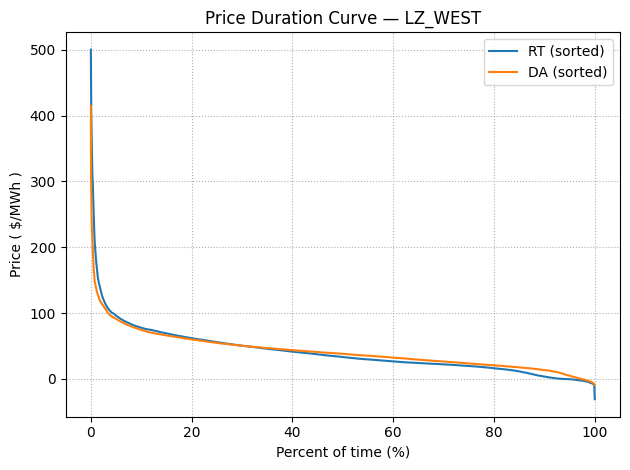

CSV files saved successfully.


In [17]:
from pyomo.environ import *
import pandas as pd
from gridstatusio import GridStatusClient
import numpy as np
import matplotlib.pyplot as plt

client = GridStatusClient(api_key="133a8efcef894b8884d82361db5f0c02")
QUERY_LIMIT = 10000

TZ = "America/Chicago"

# Define the intended ERCOT-local window
pt_start = pd.Timestamp("2025-01-01 14:00", tz=TZ)
pt_end   = pd.Timestamp("2025-12-31 14:00", tz=TZ)

# Convert to UTC for GridStatusClient
utc_start = pt_start.tz_convert("UTC").strftime("%Y-%m-%dT%H:%M:%SZ")
utc_end   = pt_end.tz_convert("UTC").strftime("%Y-%m-%dT%H:%M:%SZ")
df_RT_ERCOT = client.get_dataset(
    dataset= "ercot_lmp_by_settlement_point",
    start=utc_start,
    end=utc_end,
    filter_column = "location",
    filter_value = "LZ_WEST",
)

df_DA_ERCOT = client.get_dataset(
    dataset= "ercot_spp_day_ahead_hourly",
    start=utc_start,
    end=utc_end,
    filter_column = "location",
    filter_value = "LZ_WEST",
)

def _pick_price_col(df, preferred=None):
    """
    Return the first matching price column.
    Works with LMP (most ISOs) and SPP (ERCOT).
    """
    candidates = []
    if preferred:
        candidates.append(preferred)
    candidates += [
        "lmp", "LMP", "price", "Price",
        "spp", "SPP",
        "settlement_point_price", "Settlement Point Price"
    ]
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError("No recognized price column found. "
                   "Tried: " + ", ".join(dict.fromkeys(candidates)))

def _sorted_desc(series_like):
    s = pd.Series(series_like).astype(float).dropna()
    return s.sort_values(ascending=False).reset_index(drop=True)

def plot_pdc(
    df_rt, df_da,
    price_col_rt=None,   # e.g., "lmp" for CAISO/PJM, "spp" for ERCOT; if None, auto-detect
    price_col_da=None,
    normalize=False,     # if True, divide prices by their own mean for each series
    title_extra=None
):
    # Pick columns
    p_rt = _pick_price_col(df_rt, price_col_rt)
    p_da = _pick_price_col(df_da, price_col_da)

    # Sort high → low
    s_rt = _sorted_desc(df_rt.loc[df_rt[p_rt]<= 500,p_rt])
    s_da = _sorted_desc(df_da.loc[df_da[p_da]<= 500,p_da])

    if normalize:
        if s_rt.mean() != 0:
            s_rt = s_rt / s_rt.mean()
        if s_da.mean() != 0:
            s_da = s_da / s_da.mean()

    # X as % of time covered
    x_rt = np.linspace(0, 100, len(s_rt), endpoint=False)
    x_da = np.linspace(0, 100, len(s_da), endpoint=False)

    # Build a helpful title
    loc = None
    for cand in ["location", "Location", "Settlement Point", "node", "Node"]:
        if cand in df_rt.columns:
            loc = str(df_rt[cand].iloc[0])
            break
    if title_extra is None:
        title_extra = loc if loc else "Price Series"

    # Plot
    plt.figure()
    plt.plot(x_rt, s_rt.values, label="RT (sorted)")
    plt.plot(x_da, s_da.values, label="DA (sorted)")
    plt.xlabel("Percent of time (%)")
    plt.ylabel("Price ( $/MWh )" if not normalize else "Normalized price (÷ mean)")
    plt.title(f"Price Duration Curve — {title_extra}")
    plt.legend()
    plt.grid(True, linestyle=":")
    plt.tight_layout()
    plt.show()

plot_pdc(df_RT_ERCOT, df_DA_ERCOT, price_col_rt="lmp", price_col_da="lmp", normalize=False)

df_RT_ERCOT.to_csv(
    "df_RT_ERCOT_WEST.LZ_2025_RT_5min.csv",
    index=False
)

df_DA_ERCOT.to_csv(
    "df_DA_ERCOT_WEST.LZ_2025_DA_hourly.csv",
    index=False
)

print("CSV files saved successfully.")

2026-02-01 22:11:56 - INFO - Fetching Page 1...
2026-02-01 22:11:56 - INFO - GET https://api.gridstatus.io/v1/datasets/ercot_as_prices/query
2026-02-01 22:11:56 - INFO - Params: {'start_time': Timestamp('2025-01-01 20:00:00+0000', tz='UTC'), 'end_time': Timestamp('2025-12-31 20:00:00+0000', tz='UTC'), 'publish_time_start': None, 'publish_time_end': None, 'limit': None, 'page': 1, 'page_size': None, 'resample_frequency': None, 'resample_by': None, 'resample_function': None, 'publish_time': None, 'timezone': None, 'cursor': '', 'filter_column': None, 'filter_value': None, 'filter_operator': '=', 'return_format': 'json', 'json_schema': 'array-of-arrays'}
2026-02-01 22:11:56 - INFO - Done in 0.61 seconds. 
2026-02-01 22:11:56 - INFO - Total number of rows: 8736


Columns: ['interval_start_utc', 'interval_end_utc', 'market', 'non_spinning_reserves', 'regulation_down', 'regulation_up', 'responsive_reserves', 'ercot_contingency_reserve_service']
         interval_start_utc          interval_end_utc market  \
0 2025-01-01 20:00:00+00:00 2025-01-01 21:00:00+00:00    DAM   
1 2025-01-01 21:00:00+00:00 2025-01-01 22:00:00+00:00    DAM   
2 2025-01-01 22:00:00+00:00 2025-01-01 23:00:00+00:00    DAM   
3 2025-01-01 23:00:00+00:00 2025-01-02 00:00:00+00:00    DAM   
4 2025-01-02 00:00:00+00:00 2025-01-02 01:00:00+00:00    DAM   

   non_spinning_reserves  regulation_down  regulation_up  responsive_reserves  \
0                   0.94             0.64           1.25                 0.50   
1                   0.92             0.98           1.21                 0.46   
2                   0.98             2.13           0.94                 0.94   
3                   1.48             4.95           1.63                 2.44   
4                   2.44   

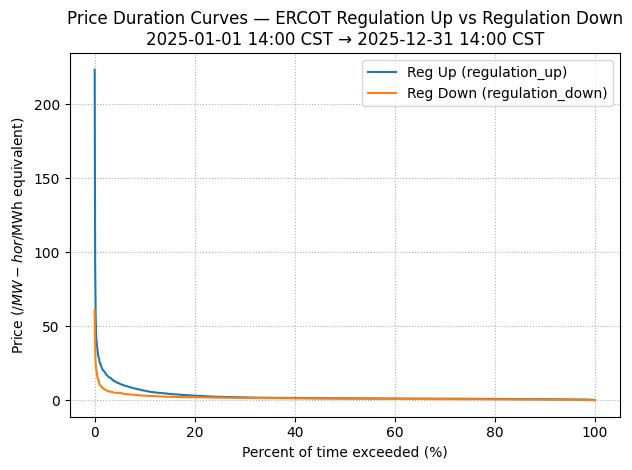

Saved: df_RMCCP_ERCOT_2025_DA.csv


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from gridstatusio import GridStatusClient

# -----------------------
# 0) Client + time window
# -----------------------
client = GridStatusClient(api_key="9b41e6e3867c42dbbdccc14af42b5515")

TZ = "America/Chicago"
pt_start = pd.Timestamp("2025-01-01 14:00", tz=TZ)
pt_end   = pd.Timestamp("2025-12-31 14:00", tz=TZ)

utc_start = pt_start.tz_convert("UTC").strftime("%Y-%m-%dT%H:%M:%SZ")
utc_end   = pt_end.tz_convert("UTC").strftime("%Y-%m-%dT%H:%M:%SZ")

# -----------------------
# 1) Download ERCOT AS prices
# -----------------------
df = client.get_dataset(
    dataset="ercot_as_prices",
    start=utc_start,
    end=utc_end,
)

print("Columns:", list(df.columns))
print(df.head())

# -----------------------
# 2) Find RegUp / RegDown columns robustly
# -----------------------
def find_col(df_cols, must_contain_any, must_not_contain=None):
    must_not_contain = must_not_contain or []
    cols = []
    for c in df_cols:
        lc = c.lower()
        if any(tok in lc for tok in must_contain_any) and not any(bad in lc for bad in must_not_contain):
            cols.append(c)
    return cols

# Common naming patterns across datasets
regup_candidates = find_col(df.columns, must_contain_any=["regulation_up", "regup", "reg up", "reg-up", "regupprice", "reg_up"])
regdn_candidates = find_col(df.columns, must_contain_any=["regulation_down", "regdown", "reg down", "reg-down", "regdownprice", "reg_down"])

if not regup_candidates or not regdn_candidates:
    raise ValueError(
        "Couldn't auto-detect RegUp/RegDown columns.\n"
        f"RegUp candidates found: {regup_candidates}\n"
        f"RegDown candidates found: {regdn_candidates}\n"
        "=> Please inspect df.columns and set regup_col/regdn_col manually."
    )

regup_col = regup_candidates[0]
regdn_col = regdn_candidates[0]
print("Using regup_col =", regup_col)
print("Using regdn_col =", regdn_col)

# -----------------------
# 3) Build comparable PDCs via exceedance-quantiles
# -----------------------
def clean_series(s, clip_max=None):
    s = pd.to_numeric(s, errors="coerce").dropna()
    if clip_max is not None:
        s = s[s <= clip_max]
    return s

def pdc_quantile_curve(series, x_exceed):
    """
    x_exceed: array in [0,100] meaning "percent of time price is exceeded"
    Convert to quantiles: q = 1 - x/100.
    """
    q = 1.0 - (x_exceed / 100.0)
    # pandas quantile accepts array-like quantiles
    return series.quantile(q).to_numpy()

def plot_pdc_two(df_in, regup_col, regdn_col, clip_max=1000, n_points=1001):
    s_up = clean_series(df_in[regup_col], clip_max=clip_max)
    s_dn = clean_series(df_in[regdn_col], clip_max=clip_max)

    if len(s_up) == 0 or len(s_dn) == 0:
        raise ValueError(f"After cleaning/clipping, empty series. len(RegUp)={len(s_up)}, len(RegDown)={len(s_dn)}")

    x = np.linspace(0, 100, n_points)  # exceedance (% time exceeded)
    y_up = pdc_quantile_curve(s_up, x)
    y_dn = pdc_quantile_curve(s_dn, x)

    plt.figure()
    plt.plot(x, y_up, label=f"Reg Up ({regup_col})")
    plt.plot(x, y_dn, label=f"Reg Down ({regdn_col})")
    plt.xlabel("Percent of time exceeded (%)")
    plt.ylabel("Price ($/MW-h or $/MWh equivalent)")
    plt.title(
        "Price Duration Curves — ERCOT Regulation Up vs Regulation Down\n"
        f"{pt_start.strftime('%Y-%m-%d %H:%M %Z')} → {pt_end.strftime('%Y-%m-%d %H:%M %Z')}"
    )
    plt.grid(True, linestyle=":")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_pdc_two(df, regup_col, regdn_col, clip_max=1000, n_points=1001)

# -----------------------
# 4) Save to CSV
# -----------------------
out_csv = "df_RMCCP_ERCOT_2025_DA.csv"
df.to_csv(out_csv, index=False)
print("Saved:", out_csv)

DA columns: ['interval_start_utc', 'interval_end_utc', 'location', 'location_type', 'market', 'spp']
RT columns: ['interval_start_utc', 'interval_end_utc', 'sced_timestamp_utc', 'market', 'location', 'location_type', 'lmp']
[RT] using time col: 'interval_start_utc', price col: 'lmp'
[DA] using time col: 'interval_start_utc', price col: 'spp'


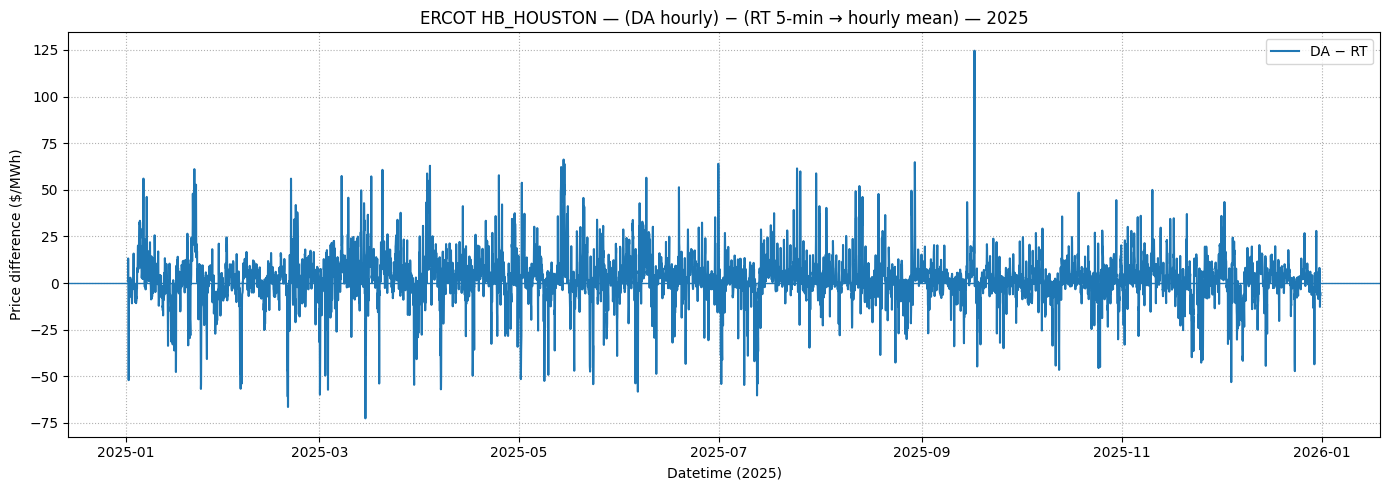

                           DA_hourly  RT_hourly_mean  DA_minus_RT
ts                                                               
2025-01-01 14:00:00-06:00      14.34       13.106667     1.233333
2025-01-01 15:00:00-06:00      14.98        1.778333    13.201667
2025-01-01 16:00:00-06:00      21.28       21.730000    -0.450000
2025-01-01 17:00:00-06:00      36.75       46.424167    -9.674167
2025-01-01 18:00:00-06:00      33.13       72.580833   -39.450833


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


def load_table(path: str) -> pd.DataFrame:
    """
    Load a table from CSV or Excel, based on file extension.
    """
    p = path.lower()
    if p.endswith(".csv"):
        return pd.read_csv(path)
    if p.endswith((".xls", ".xlsx")):
        return pd.read_excel(path)
    raise ValueError(f"Unsupported file type: {path}")


def plot_da_minus_rt(
    df_rt: pd.DataFrame,
    df_da: pd.DataFrame,
    price_col: str = "lmp",            # try this first; will auto-detect if missing
    clip_low: float = -500,
    clip_high: float = 500,
    tz_plot: str = "America/Chicago",
    rt_hourly_method: str = "mean",    # "mean" | "median" | "last"
    title: str = "ERCOT HB_HOUSTON — (DA hourly) − (RT 5-min → hourly) — 2025",
    verbose: bool = True,
) -> pd.DataFrame:
    """
    Plots time-aligned difference:
        diff(t) = DA_hourly(t) - RT_hourly(t)
    with RT resampled from 5-min to hourly (mean/median/last).
    Prices are clipped to [clip_low, clip_high] BEFORE differencing.
    """

    # --- Find a datetime column robustly ---
    def _get_time_col(df: pd.DataFrame) -> str:
        for c in ["interval_start_utc", "interval_start", "time", "timestamp", "datetime"]:
            if c in df.columns:
                return c
        for c in df.columns:
            try:
                if np.issubdtype(df[c].dtype, np.datetime64):
                    return c
            except Exception:
                pass
        raise ValueError("No datetime column found. Columns:\n" + ", ".join(map(str, df.columns)))

    # --- Choose a price column robustly ---
    def _pick_price_col(df: pd.DataFrame, preferred: str) -> str:
        # exact match
        if preferred in df.columns:
            return preferred

        # case-insensitive match
        lower_map = {c.lower(): c for c in df.columns if isinstance(c, str)}
        if preferred.lower() in lower_map:
            return lower_map[preferred.lower()]

        # common alternatives across ISOs/datasets
        candidates = [
            "price",
            "lmp",
            "da_lmp",
            "rt_lmp",
            "market_price",
            "settlement_point_price",
            "settlement_point_price_dollar_per_mwh",
            "lbmp",
            "mp",
            "value",
        ]
        for c in candidates:
            if c in df.columns:
                return c
            if isinstance(c, str) and c.lower() in lower_map:
                return lower_map[c.lower()]

        # fallback: first numeric column that isn't obviously a date-part
        numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        for c in numeric_cols:
            if str(c).lower() not in {"year", "month", "day", "hour", "minute"}:
                return c

        raise KeyError(
            f"Could not find a price column. Preferred '{preferred}' not found.\n"
            f"Columns are:\n{list(df.columns)}"
        )

    rt_time_col = _get_time_col(df_rt)
    da_time_col = _get_time_col(df_da)

    rt_price_col = _pick_price_col(df_rt, price_col)
    da_price_col = _pick_price_col(df_da, price_col)

    if verbose:
        print(f"[RT] using time col: '{rt_time_col}', price col: '{rt_price_col}'")
        print(f"[DA] using time col: '{da_time_col}', price col: '{da_price_col}'")

    # --- Prep RT ---
    rt = df_rt[[rt_time_col, rt_price_col]].copy()
    rt[rt_time_col] = pd.to_datetime(rt[rt_time_col], utc=True, errors="coerce")
    rt = rt.dropna(subset=[rt_time_col, rt_price_col]).sort_values(rt_time_col)

    rt["ts"] = rt[rt_time_col].dt.tz_convert(tz_plot)
    rt["price"] = pd.to_numeric(rt[rt_price_col], errors="coerce").clip(lower=clip_low, upper=clip_high)
    rt = rt.dropna(subset=["price"]).set_index("ts")[["price"]]

    # RT 5-min -> hourly
    if rt_hourly_method == "mean":
        rt_h = rt.resample("h").mean()
    elif rt_hourly_method == "median":
        rt_h = rt.resample("h").median()
    elif rt_hourly_method == "last":
        rt_h = rt.resample("h").last()
    else:
        raise ValueError("rt_hourly_method must be one of: mean, median, last")

    rt_h = rt_h.rename(columns={"price": f"RT_hourly_{rt_hourly_method}"})

    # --- Prep DA ---
    da = df_da[[da_time_col, da_price_col]].copy()
    da[da_time_col] = pd.to_datetime(da[da_time_col], utc=True, errors="coerce")
    da = da.dropna(subset=[da_time_col, da_price_col]).sort_values(da_time_col)

    da["ts"] = da[da_time_col].dt.tz_convert(tz_plot)
    da["price"] = pd.to_numeric(da[da_price_col], errors="coerce").clip(lower=clip_low, upper=clip_high)
    da = da.dropna(subset=["price"]).set_index("ts")[["price"]].rename(columns={"price": "DA_hourly"})

    # normalize DA to hourly index
    da_h = da.resample("h").mean()

    # --- Align + difference ---
    merged = da_h.join(rt_h, how="inner")
    merged["DA_minus_RT"] = merged["DA_hourly"] - merged[f"RT_hourly_{rt_hourly_method}"]

    # --- Plot ---
    plt.figure(figsize=(14, 5))
    plt.plot(merged.index, merged["DA_minus_RT"], label="DA − RT")
    plt.axhline(0, linewidth=1)
    plt.xlabel("Datetime (2025)")
    plt.ylabel("Price difference ($/MWh)")
    plt.title(title)
    plt.grid(True, linestyle=":")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return merged


# =========================
# Load saved DA/RT files (CSV or Excel) — NO API calls
# =========================
# Option A: relative paths (recommended if your cwd is already C:\Users\hsofi\EVC)
da_path = r"C:\Users\hsofi\EVC\df_DA_ERCOT_HOUSTON.HUB_2025_DA_hourly.csv"
rt_path = r"C:\Users\hsofi\EVC\df_RT_ERCOT_HOUSTON.HUB_2025_RT_5min.csv"

df_DA = load_table(da_path)
df_RT = load_table(rt_path)

print("DA columns:", df_DA.columns.tolist())
print("RT columns:", df_RT.columns.tolist())


# =========================
# Run (ERCOT example)
# =========================
diff_df = plot_da_minus_rt(
    df_rt=df_RT,
    df_da=df_DA,
    price_col="lmp",          # OK to leave; function will auto-detect if missing
    clip_low=-100,
    clip_high=100,
    tz_plot="America/Chicago",
    rt_hourly_method="mean",
    title="ERCOT HB_HOUSTON — (DA hourly) − (RT 5-min → hourly mean) — 2025",
    verbose=True,
)

print(diff_df.head())


In [16]:
def dart_extreme_metrics(
    diff_df: pd.DataFrame,
    dart_col="DA_minus_RT",
    threshold=30.0,
):
    """
    Quantify frequency and magnitude of extreme DART spreads.

    Returns a dict of metrics.
    """

    x = diff_df[dart_col].dropna()
    n = len(x)

    if n == 0:
        raise ValueError("No valid DART values found.")

    pos = x[x > threshold]
    neg = x[x < -threshold]
    extreme = x[np.abs(x) > threshold]

    metrics = {
        # ---- counts ----
        "n_hours_total": n,
        "n_hours_DART_gt_30": len(pos),
        "n_hours_DART_lt_-30": len(neg),
        "n_hours_abs_DART_gt_30": len(extreme),

        # ---- frequencies ----
        "pct_hours_DART_gt_30": 100 * len(pos) / n,
        "pct_hours_DART_lt_-30": 100 * len(neg) / n,
        "pct_hours_abs_DART_gt_30": 100 * len(extreme) / n,

        # ---- magnitudes (conditional) ----
        "mean_DART_gt_30": pos.mean() if len(pos) > 0 else np.nan,
        "mean_DART_lt_-30": neg.mean() if len(neg) > 0 else np.nan,
        "max_DART": x.max(),
        "min_DART": x.min(),

        # ---- aggregate severity ----
        "sum_abs_DART_gt_30": np.abs(extreme).sum(),
        "mean_abs_DART_gt_30": np.abs(extreme).mean() if len(extreme) > 0 else np.nan,
    }

    return metrics
dart_metrics = dart_extreme_metrics(
    diff_df,
    dart_col="DA_minus_RT",
    threshold=30,
)

pd.Series(dart_metrics)

n_hours_total                8736.000000
n_hours_DART_gt_30            187.000000
n_hours_DART_lt_-30           165.000000
n_hours_abs_DART_gt_30        352.000000
pct_hours_DART_gt_30            2.140568
pct_hours_DART_lt_-30           1.888736
pct_hours_abs_DART_gt_30        4.029304
mean_DART_gt_30                41.943175
mean_DART_lt_-30              -41.508213
max_DART                      124.570000
min_DART                      -72.511333
sum_abs_DART_gt_30          14692.228845
mean_abs_DART_gt_30            41.739286
dtype: float64

2026-02-15 13:28:04 - INFO - Fetching Page 1...
2026-02-15 13:28:04 - INFO - GET https://api.gridstatus.io/v1/datasets/caiso_lmp_real_time_5_min/query
2026-02-15 13:28:04 - INFO - Params: {'start_time': Timestamp('2025-01-01 22:00:00+0000', tz='UTC'), 'end_time': Timestamp('2025-12-31 22:00:00+0000', tz='UTC'), 'publish_time_start': None, 'publish_time_end': None, 'limit': None, 'page': 1, 'page_size': None, 'resample_frequency': None, 'resample_by': None, 'resample_function': None, 'publish_time': None, 'timezone': None, 'cursor': '', 'filter_column': 'location', 'filter_value': 'DLAP_PACW_NPM-APND', 'filter_operator': '=', 'return_format': 'json', 'json_schema': 'array-of-arrays'}
2026-02-15 13:28:06 - INFO - Done in 2.11 seconds. 
2026-02-15 13:28:06 - INFO - Fetching Page 2...
2026-02-15 13:28:06 - INFO - GET https://api.gridstatus.io/v1/datasets/caiso_lmp_real_time_5_min/query
2026-02-15 13:28:06 - INFO - Params: {'start_time': Timestamp('2025-01-01 22:00:00+0000', tz='UTC'), 'end

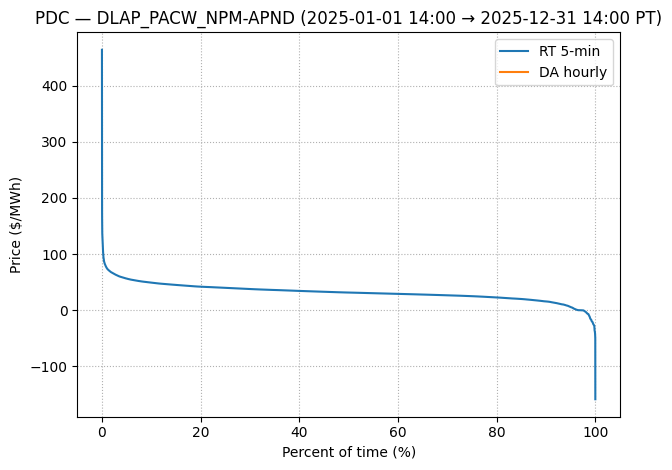

CSV files saved successfully.


In [25]:
from pyomo.environ import *
import pandas as pd
from gridstatusio import GridStatusClient
import numpy as np
import matplotlib.pyplot as plt

client = GridStatusClient(api_key="76e95e669c424a95b7f0bdcdda8c3643")
QUERY_LIMIT = 10000

TZ = "America/Los_Angeles"

# Define the intended CAISO-local window
pt_start = pd.Timestamp("2025-01-01 14:00", tz=TZ)
pt_end   = pd.Timestamp("2025-12-31 14:00", tz=TZ)

# Convert to UTC for GridStatusClient
utc_start = pt_start.tz_convert("UTC").strftime("%Y-%m-%dT%H:%M:%SZ")
utc_end   = pt_end.tz_convert("UTC").strftime("%Y-%m-%dT%H:%M:%SZ")
df_RT_CAISO = client.get_dataset(
    dataset= "caiso_lmp_real_time_5_min",
    start=utc_start,
    end=utc_end,
    filter_column = "location",
    filter_value = "DLAP_PACW_NPM-APND",
)

df_DA_CAISO = client.get_dataset(
    dataset= "caiso_lmp_day_ahead_hourly",
    start=utc_start,
    end=utc_end,
    filter_column = "location",
    filter_value = "DLAP_PACW_NPM-APND",
)

def _sorted_desc(series_like):
    s = pd.Series(series_like).astype(float).dropna()
    return s.sort_values(ascending=False).reset_index(drop=True)

def plot_pdc(df_rt, df_da, price_col="lmp", label_rt="RT 5-min", label_da="DA hourly",
             title_extra="DLAP_PACW_NPM-APND (2025-01-01 14:00 → 2025-12-31 14:00 PT)"):
    # Sort prices high→low
    s_rt = _sorted_desc(df_rt.loc[df_rt[price_col]<= 500,price_col])
    s_da = _sorted_desc(df_da.loc[df_da[price_col]<= 500,price_col])

    # X-axis as % of time covered
    x_rt = np.linspace(0, 100, len(s_rt), endpoint=False)
    x_da = np.linspace(0, 100, len(s_da), endpoint=False)

    # Plot both curves on the same axes
    plt.figure()
    plt.plot(x_rt, s_rt.values, label=label_rt)
    plt.plot(x_da, s_da.values, label=label_da)
    plt.xlabel("Percent of time (%)")
    plt.ylabel("Price ($/MWh)")
    plt.title(f"PDC — {title_extra}")
    plt.legend()
    plt.grid(True, linestyle=":")
    plt.tight_layout()
    plt.show()

# Call it (uses your df_RT and df_DA)
plot_pdc(df_RT_CAISO, df_DA_CAISO)

df_RT_CAISO.to_csv(
    "df_RT_CAISO_DLAP_PACW_NPM-APND_2025_RT_5min.csv",
    index=False
)

df_DA_CAISO.to_csv(
    "df_DA_CAISO_DLAP_PACW_NPM-APND_2025_DA_hourly.csv",
    index=False
)

print("CSV files saved successfully.")

2026-02-01 22:46:27 - INFO - Fetching Page 1...
2026-02-01 22:46:27 - INFO - GET https://api.gridstatus.io/v1/datasets/caiso_as_prices/query
2026-02-01 22:46:27 - INFO - Params: {'start_time': Timestamp('2025-01-01 22:00:00+0000', tz='UTC'), 'end_time': Timestamp('2025-12-31 22:00:00+0000', tz='UTC'), 'publish_time_start': None, 'publish_time_end': None, 'limit': None, 'page': 1, 'page_size': None, 'resample_frequency': None, 'resample_by': None, 'resample_function': None, 'publish_time': None, 'timezone': None, 'cursor': '', 'filter_column': 'region', 'filter_value': 'AS_CAISO_EXP', 'filter_operator': '=', 'return_format': 'json', 'json_schema': 'array-of-arrays'}
2026-02-01 22:46:28 - INFO - Done in 0.95 seconds. 
2026-02-01 22:46:28 - INFO - Total number of rows: 8736


Columns: ['interval_start_utc', 'interval_end_utc', 'region', 'market', 'non_spinning_reserves', 'regulation_down', 'regulation_mileage_down', 'regulation_mileage_up', 'regulation_up', 'spinning_reserves']
         interval_start_utc          interval_end_utc        region market  \
0 2025-01-01 22:00:00+00:00 2025-01-01 23:00:00+00:00  AS_CAISO_EXP    DAM   
1 2025-01-01 23:00:00+00:00 2025-01-02 00:00:00+00:00  AS_CAISO_EXP    DAM   
2 2025-01-02 00:00:00+00:00 2025-01-02 01:00:00+00:00  AS_CAISO_EXP    DAM   
3 2025-01-02 01:00:00+00:00 2025-01-02 02:00:00+00:00  AS_CAISO_EXP    DAM   
4 2025-01-02 02:00:00+00:00 2025-01-02 03:00:00+00:00  AS_CAISO_EXP    DAM   

   non_spinning_reserves  regulation_down  regulation_mileage_down  \
0                 0.1400          5.98847                     0.01   
1                 0.1400          7.00000                     0.00   
2                 0.1400          3.91000                     0.10   
3                 0.4077          4.01000    

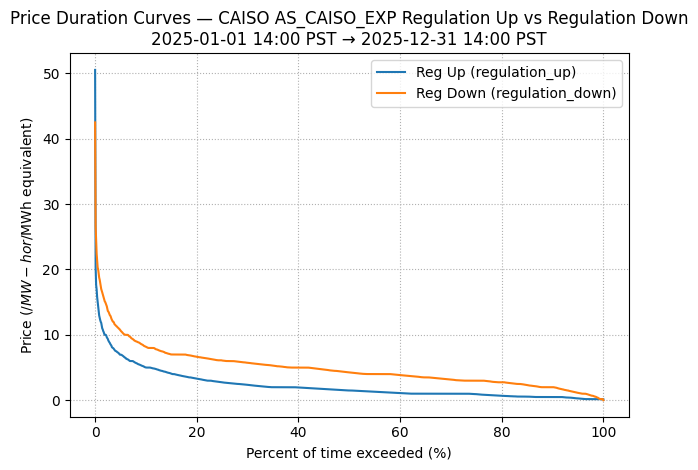

Saved: df_RMCCP_CAISO_AS_CAISO_EXP_2025_DA.csv


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from gridstatusio import GridStatusClient

# -----------------------
# 0) Client + time window
# -----------------------
client = GridStatusClient(api_key="9b41e6e3867c42dbbdccc14af42b5515")

TZ = "America/Los_Angeles"
pt_start = pd.Timestamp("2025-01-01 14:00", tz=TZ)
pt_end   = pd.Timestamp("2025-12-31 14:00", tz=TZ)

utc_start = pt_start.tz_convert("UTC").strftime("%Y-%m-%dT%H:%M:%SZ")
utc_end   = pt_end.tz_convert("UTC").strftime("%Y-%m-%dT%H:%M:%SZ")

# -----------------------
# 1) Download ERCOT AS prices
# -----------------------
df = client.get_dataset(
    dataset="caiso_as_prices",
    start=utc_start,
    end=utc_end,
    filter_column = "region",
    filter_value = "AS_CAISO_EXP",
)

print("Columns:", list(df.columns))
print(df.head())

# -----------------------
# 2) Find RegUp / RegDown columns robustly
# -----------------------
def find_col(df_cols, must_contain_any, must_not_contain=None):
    must_not_contain = must_not_contain or []
    cols = []
    for c in df_cols:
        lc = c.lower()
        if any(tok in lc for tok in must_contain_any) and not any(bad in lc for bad in must_not_contain):
            cols.append(c)
    return cols

# Common naming patterns across datasets
regup_candidates = find_col(df.columns, must_contain_any=["regulation_up", "regup", "reg up", "reg-up", "regupprice", "reg_up"])
regdn_candidates = find_col(df.columns, must_contain_any=["regulation_down", "regdown", "reg down", "reg-down", "regdownprice", "reg_down"])

if not regup_candidates or not regdn_candidates:
    raise ValueError(
        "Couldn't auto-detect RegUp/RegDown columns.\n"
        f"RegUp candidates found: {regup_candidates}\n"
        f"RegDown candidates found: {regdn_candidates}\n"
        "=> Please inspect df.columns and set regup_col/regdn_col manually."
    )

regup_col = regup_candidates[0]
regdn_col = regdn_candidates[0]
print("Using regup_col =", regup_col)
print("Using regdn_col =", regdn_col)

# -----------------------
# 3) Build comparable PDCs via exceedance-quantiles
# -----------------------
def clean_series(s, clip_max=None):
    s = pd.to_numeric(s, errors="coerce").dropna()
    if clip_max is not None:
        s = s[s <= clip_max]
    return s

def pdc_quantile_curve(series, x_exceed):
    """
    x_exceed: array in [0,100] meaning "percent of time price is exceeded"
    Convert to quantiles: q = 1 - x/100.
    """
    q = 1.0 - (x_exceed / 100.0)
    # pandas quantile accepts array-like quantiles
    return series.quantile(q).to_numpy()

def plot_pdc_two(df_in, regup_col, regdn_col, clip_max=1000, n_points=1001):
    s_up = clean_series(df_in[regup_col], clip_max=clip_max)
    s_dn = clean_series(df_in[regdn_col], clip_max=clip_max)

    if len(s_up) == 0 or len(s_dn) == 0:
        raise ValueError(f"After cleaning/clipping, empty series. len(RegUp)={len(s_up)}, len(RegDown)={len(s_dn)}")

    x = np.linspace(0, 100, n_points)  # exceedance (% time exceeded)
    y_up = pdc_quantile_curve(s_up, x)
    y_dn = pdc_quantile_curve(s_dn, x)

    plt.figure()
    plt.plot(x, y_up, label=f"Reg Up ({regup_col})")
    plt.plot(x, y_dn, label=f"Reg Down ({regdn_col})")
    plt.xlabel("Percent of time exceeded (%)")
    plt.ylabel("Price ($/MW-h or $/MWh equivalent)")
    plt.title(
        "Price Duration Curves — CAISO AS_CAISO_EXP Regulation Up vs Regulation Down\n"
        f"{pt_start.strftime('%Y-%m-%d %H:%M %Z')} → {pt_end.strftime('%Y-%m-%d %H:%M %Z')}"
    )
    plt.grid(True, linestyle=":")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_pdc_two(df, regup_col, regdn_col, clip_max=1000, n_points=1001)

# -----------------------
# 4) Save to CSV
# -----------------------
out_csv = "df_RMCCP_CAISO_AS_CAISO_EXP_2025_DA.csv"
df.to_csv(out_csv, index=False)
print("Saved:", out_csv)

DA columns: ['interval_start_utc', 'interval_end_utc', 'market', 'location', 'location_type', 'lmp', 'energy', 'congestion', 'loss']
RT columns: ['interval_start_utc', 'interval_end_utc', 'market', 'location', 'location_type', 'lmp', 'energy', 'congestion', 'loss', 'ghg']


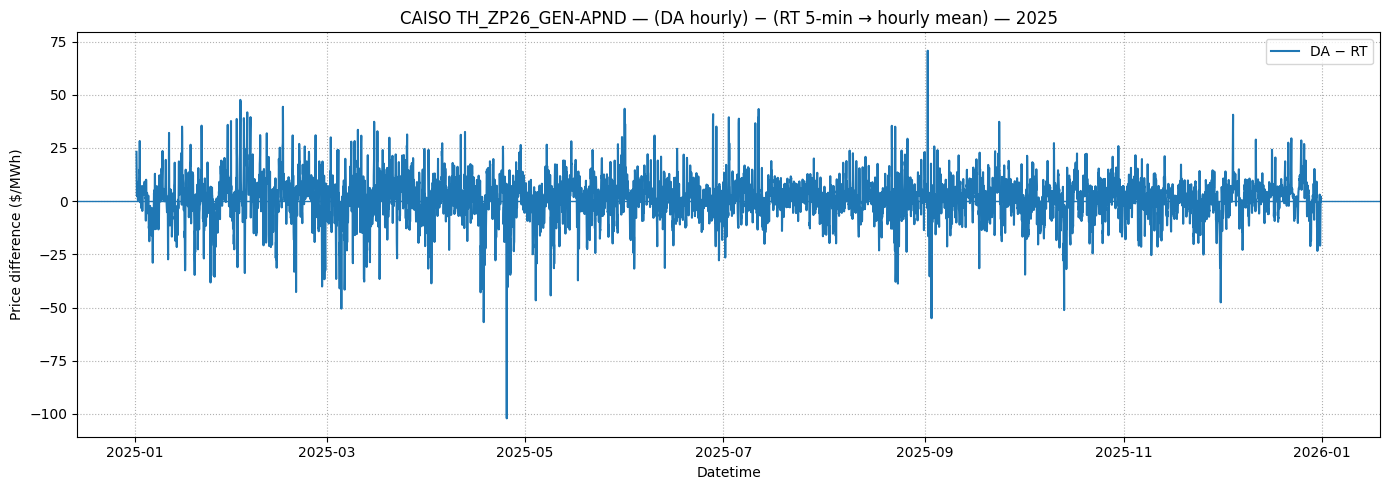

                           DA_hourly  RT_hourly_mean  DA_minus_RT
ts                                                               
2025-01-01 14:00:00-08:00   20.19823       -3.013080    23.211310
2025-01-01 15:00:00-08:00   29.71476       14.902437    14.812322
2025-01-01 16:00:00-08:00   43.83167       39.812980     4.018690
2025-01-01 17:00:00-08:00   44.16419       41.604962     2.559228
2025-01-01 18:00:00-08:00   43.97594       38.697844     5.278096


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


def plot_da_minus_rt(
    df_rt: pd.DataFrame,
    df_da: pd.DataFrame,
    price_col: str = "lmp",
    clip_low: float = -500,
    clip_high: float = 500,
    tz_plot: str = "America/Los_Angeles",
    rt_hourly_method: str = "mean",  # "mean" | "median" | "last"
    title: str = "CAISO TH_ZP26_GEN-APND — (DA hourly) − (RT 5-min → hourly) — 2025",
) -> pd.DataFrame:
    """
    Plots the time-aligned difference:
        diff(t) = DA_hourly(t) - RT_hourly(t)

    Assumptions:
      - df_da is hourly (or close enough to resample to hourly)
      - df_rt is 5-min (or close enough to resample to hourly)

    Notes:
      - We clip prices to [clip_low, clip_high] BEFORE differencing.
      - We join on hourly timestamps (inner join), keeping only hours present in both.
    """

    # --- Find a datetime column robustly (GridStatus datasets vary) ---
    def _get_time_col(df: pd.DataFrame) -> str:
        preferred = ["interval_start_utc", "interval_start", "time", "timestamp", "datetime"]
        for c in preferred:
            if c in df.columns:
                return c

        # fallback: pick the first datetime-like column
        for c in df.columns:
            try:
                if np.issubdtype(df[c].dtype, np.datetime64):
                    return c
            except Exception:
                pass

        raise ValueError(
            "No datetime column found. Available columns:\n" + ", ".join(map(str, df.columns))
        )

    rt_time_col = _get_time_col(df_rt)
    da_time_col = _get_time_col(df_da)

    # --- Guard: ensure price column exists (case mismatch is common after exports) ---
    def _resolve_price_col(df: pd.DataFrame, col: str) -> str:
        if col in df.columns:
            return col
        # try common case-insensitive match
        lower_map = {c.lower(): c for c in df.columns if isinstance(c, str)}
        if col.lower() in lower_map:
            return lower_map[col.lower()]
        raise KeyError(
            f"Price column '{col}' not found. Available columns:\n" + ", ".join(map(str, df.columns))
        )

    rt_price_col = _resolve_price_col(df_rt, price_col)
    da_price_col = _resolve_price_col(df_da, price_col)

    # --- Prep RT ---
    rt = df_rt[[rt_time_col, rt_price_col]].copy()
    rt[rt_time_col] = pd.to_datetime(rt[rt_time_col], utc=True, errors="coerce")
    rt = rt.dropna(subset=[rt_time_col, rt_price_col]).sort_values(rt_time_col)

    rt["ts"] = rt[rt_time_col].dt.tz_convert(tz_plot)
    rt["price"] = pd.to_numeric(rt[rt_price_col], errors="coerce").clip(lower=clip_low, upper=clip_high)
    rt = rt.dropna(subset=["price"]).set_index("ts")[["price"]]

    # Resample RT -> hourly
    if rt_hourly_method == "mean":
        rt_h = rt.resample("h").mean()
    elif rt_hourly_method == "median":
        rt_h = rt.resample("h").median()
    elif rt_hourly_method == "last":
        rt_h = rt.resample("h").last()
    else:
        raise ValueError("rt_hourly_method must be one of: 'mean', 'median', 'last'")

    rt_h = rt_h.rename(columns={"price": f"RT_hourly_{rt_hourly_method}"})

    # --- Prep DA ---
    da = df_da[[da_time_col, da_price_col]].copy()
    da[da_time_col] = pd.to_datetime(da[da_time_col], utc=True, errors="coerce")
    da = da.dropna(subset=[da_time_col, da_price_col]).sort_values(da_time_col)

    da["ts"] = da[da_time_col].dt.tz_convert(tz_plot)
    da["price"] = pd.to_numeric(da[da_price_col], errors="coerce").clip(lower=clip_low, upper=clip_high)
    da = da.dropna(subset=["price"]).set_index("ts")[["price"]].rename(columns={"price": "DA_hourly"})

    # Enforce hourly indexing
    da_h = da.resample("h").mean()

    # --- Align + compute difference ---
    merged = da_h.join(rt_h, how="inner")
    merged["DA_minus_RT"] = merged["DA_hourly"] - merged[f"RT_hourly_{rt_hourly_method}"]

    # --- Plot ---
    plt.figure(figsize=(14, 5))
    plt.plot(merged.index, merged["DA_minus_RT"], label="DA − RT")
    plt.axhline(0, linewidth=1)
    plt.xlabel("Datetime")
    plt.ylabel("Price difference ($/MWh)")
    plt.title(title)
    plt.grid(True, linestyle=":")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return merged


# =========================
# Load your saved files (.xls) ONCE (no API calls)
# =========================
da_path = r"C:\Users\hsofi\EVC\df_DA_CAISO_TH_ZP26_GEN-APND_2025_DA_hourly.csv"
rt_path = r"C:\Users\hsofi\EVC\df_RT_CAISO_TH_ZP26_GEN-APND_2025_RT_5min.csv"

df_DA = pd.read_csv(da_path)
df_RT = pd.read_csv(rt_path)

# (Optional) quick sanity check
print("DA columns:", list(df_DA.columns))
print("RT columns:", list(df_RT.columns))

# =========================
# Run
# =========================
diff_df = plot_da_minus_rt(
    df_rt=df_RT,
    df_da=df_DA,
    price_col="lmp",                 # will also match "LMP" automatically
    clip_low=-100,
    clip_high=100,
    tz_plot="America/Los_Angeles",
    rt_hourly_method="mean",
    title="CAISO TH_ZP26_GEN-APND — (DA hourly) − (RT 5-min → hourly mean) — 2025",
)

# diff_df now contains: DA_hourly, RT_hourly_mean, DA_minus_RT
print(diff_df.head())


2026-02-02 12:15:40 - INFO - Fetching Page 1...
2026-02-02 12:15:40 - INFO - GET https://api.gridstatus.io/v1/datasets/pjm_as_market_results_real_time/query
2026-02-02 12:15:40 - INFO - Params: {'start_time': Timestamp('2025-01-01 19:00:00+0000', tz='UTC'), 'end_time': Timestamp('2025-12-31 19:00:00+0000', tz='UTC'), 'publish_time_start': None, 'publish_time_end': None, 'limit': None, 'page': 1, 'page_size': None, 'resample_frequency': None, 'resample_by': None, 'resample_function': None, 'publish_time': None, 'timezone': None, 'cursor': '', 'filter_column': 'service_type', 'filter_value': 'Regulation', 'filter_operator': '=', 'return_format': 'json', 'json_schema': 'array-of-arrays'}
2026-02-02 12:15:43 - INFO - Done in 2.5 seconds. 
2026-02-02 12:15:43 - INFO - Fetching Page 2...
2026-02-02 12:15:43 - INFO - GET https://api.gridstatus.io/v1/datasets/pjm_as_market_results_real_time/query
2026-02-02 12:15:43 - INFO - Params: {'start_time': Timestamp('2025-01-01 19:00:00+0000', tz='UTC'

PJM columns: ['interval_start_utc', 'interval_end_utc', 'ancillary_service', 'locale', 'service_type', 'market_clearing_price', 'market_clearing_price_capped', 'regulation_capability_clearing_price', 'regulation_performance_clearing_price', 'ancillary_service_required', 'total_mw', 'assigned_mw', 'self_scheduled_mw', 'tier_1_mw', 'interface_reserve_capability_mw', 'demand_response_mw_assigned', 'non_synchronized_reserve_mw_assigned', 'regd_mw']
PJM price_col: regulation_capability_clearing_price


2026-02-02 12:15:50 - INFO - Done in 2.54 seconds. 
2026-02-02 12:15:50 - INFO - Fetching Page 2...
2026-02-02 12:15:50 - INFO - GET https://api.gridstatus.io/v1/datasets/nyiso_as_prices_real_time_5_min/query
2026-02-02 12:15:50 - INFO - Params: {'start_time': Timestamp('2025-01-01 19:00:00+0000', tz='UTC'), 'end_time': Timestamp('2025-12-31 19:00:00+0000', tz='UTC'), 'publish_time_start': None, 'publish_time_end': None, 'limit': None, 'page': 2, 'page_size': None, 'resample_frequency': None, 'resample_by': None, 'resample_function': None, 'publish_time': None, 'timezone': None, 'cursor': 'eyJjb2x1bW5zIjpbImludGVydmFsX3N0YXJ0X3V0YyIsInpvbmUiXSwidmFsdWVzIjpbIjIwMjUtMDYtMjAgMTM6MzA6MDArMDA6MDAiLCJDQVBJVEwiXSwidG90YWxfcm93c19yZXR1cm5lZF9zb19mYXIiOjUwMDAwfQ==', 'filter_column': 'zone', 'filter_value': 'CAPITL', 'filter_operator': '=', 'return_format': 'json', 'json_schema': 'array-of-arrays'}
2026-02-02 12:15:52 - INFO - Done in 1.63 seconds. Total time: 4.17s. Avg per page: 2.09s
2026-02-

NYISO columns: ['interval_start_utc', 'interval_end_utc', 'zone', 'spin_reserves_10_min', 'non_spin_reserves_10_min', 'reserves_30_min', 'regulation_capacity']
NYISO price_col: regulation_capacity


2026-02-02 12:15:56 - INFO - Done in 2.82 seconds. 
2026-02-02 12:15:56 - INFO - Fetching Page 2...
2026-02-02 12:15:56 - INFO - GET https://api.gridstatus.io/v1/datasets/isone_regulation_clearing_prices_real_time_5_min/query
2026-02-02 12:15:56 - INFO - Params: {'start_time': Timestamp('2025-01-01 19:00:00+0000', tz='UTC'), 'end_time': Timestamp('2025-12-31 19:00:00+0000', tz='UTC'), 'publish_time_start': None, 'publish_time_end': None, 'limit': None, 'page': 2, 'page_size': None, 'resample_frequency': None, 'resample_by': None, 'resample_function': None, 'publish_time': None, 'timezone': None, 'cursor': 'eyJjb2x1bW5zIjpbImludGVydmFsX3N0YXJ0X3V0YyJdLCJ2YWx1ZXMiOlsiMjAyNS0wNi0yNCAxNzozNTowMCswMDowMCJdLCJ0b3RhbF9yb3dzX3JldHVybmVkX3NvX2ZhciI6NTAwMDB9', 'filter_column': None, 'filter_value': None, 'filter_operator': '=', 'return_format': 'json', 'json_schema': 'array-of-arrays'}
2026-02-02 12:15:57 - INFO - Done in 1.41 seconds. Total time: 4.22s. Avg per page: 2.11s
2026-02-02 12:15:57 -

ISONE columns: ['interval_start_utc', 'interval_end_utc', 'reg_service_clearing_price', 'reg_capacity_clearing_price']
ISONE price_col: reg_capacity_clearing_price


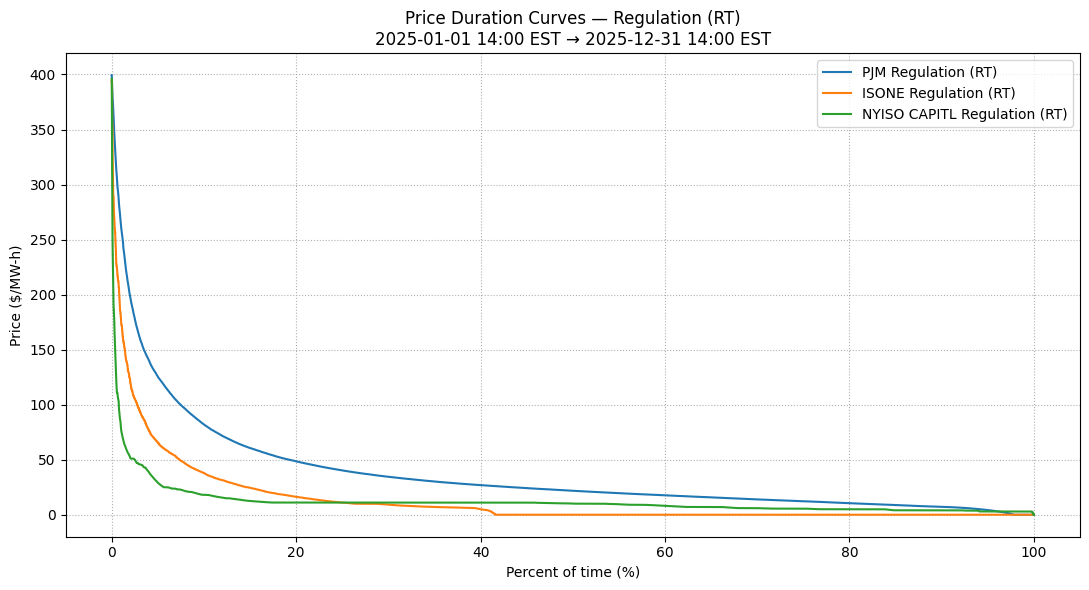

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from gridstatusio import GridStatusClient

# =========================
# USER SETTINGS
# =========================
API_KEY = "76e0e2ac84aa47d69a6f019c1abf044b"   # better: read from env var
TZ = "America/New_York"

pt_start = pd.Timestamp("2025-01-01 14:00", tz=TZ)
pt_end   = pd.Timestamp("2025-12-31 14:00", tz=TZ)

CLIP_MAX = 400  # None to disable clipping

# =========================
# TIME CONVERSION (GridStatus expects UTC strings)
# =========================
utc_start = pt_start.tz_convert("UTC").strftime("%Y-%m-%dT%H:%M:%SZ")
utc_end   = pt_end.tz_convert("UTC").strftime("%Y-%m-%dT%H:%M:%SZ")

client = GridStatusClient(api_key=API_KEY)

# =========================
# HELPERS
# =========================
def find_price_col(df: pd.DataFrame, keywords):
    """
    Find a likely price column by checking whether all keywords appear in the column name (lowercased).
    keywords: list[str]
    """
    cols_lower = {c: c.lower() for c in df.columns}
    hits = [c for c, cl in cols_lower.items() if all(k in cl for k in keywords)]
    if not hits:
        raise ValueError(
            f"Couldn't find a price column using keywords={keywords}. "
            f"Available columns:\n{list(df.columns)}\n"
            f"Set the price column manually."
        )
    return hits[0]

def pdc_xy(df: pd.DataFrame, price_col: str, clip_max=CLIP_MAX):
    """Return (x_percent, y_sorted_desc) for a price duration curve."""
    s = pd.to_numeric(df[price_col], errors="coerce").dropna()
    if clip_max is not None:
        s = s[s <= clip_max]
    s_sorted = s.sort_values(ascending=False).reset_index(drop=True)

    x = 100.0 * (np.arange(len(s_sorted)) / len(s_sorted))  # 0..100
    y = s_sorted.values
    return x, y

# =========================
# 1) PJM — RT AS market results (Regulation)
# =========================
df_pjm = client.get_dataset(
    dataset="pjm_as_market_results_real_time",
    start=utc_start,
    end=utc_end,
    filter_column="service_type",
    filter_value="Regulation",
)

# Try to detect PJM RMCCP column
# (Your earlier code searched for "regulation_capability_clearing_price")
pjm_price_col = find_price_col(df_pjm, ["regulation", "clearing", "price"])
print("PJM columns:", list(df_pjm.columns))
print("PJM price_col:", pjm_price_col)

# =========================
# 2) NYISO — RT AS prices 5-min (Zone = CAPITL)
# =========================
df_nyiso = client.get_dataset(
    dataset="nyiso_as_prices_real_time_5_min",
    start=utc_start,
    end=utc_end,
    filter_column="zone",
    filter_value="CAPITL",
)

# Try to detect NYISO regulation capacity price column
nyiso_price_col = find_price_col(df_nyiso, ["regulation", "capacity"])
print("NYISO columns:", list(df_nyiso.columns))
print("NYISO price_col:", nyiso_price_col)

# =========================
# 3) ISONE — RT regulation clearing prices 5-min
# =========================
df_isone = client.get_dataset(
    dataset="isone_regulation_clearing_prices_real_time_5_min",
    start=utc_start,
    end=utc_end,
)

# Try to detect ISONE reg capacity clearing price column
isone_price_col = find_price_col(df_isone, ["reg", "capacity", "price"])
print("ISONE columns:", list(df_isone.columns))
print("ISONE price_col:", isone_price_col)

# =========================
# 4) BUILD PDCs + PLOT ON ONE FIGURE
# =========================
x_pjm,   y_pjm   = pdc_xy(df_pjm,   pjm_price_col,   clip_max=CLIP_MAX)
x_isone, y_isone = pdc_xy(df_isone, isone_price_col, clip_max=CLIP_MAX)
x_nyiso, y_nyiso = pdc_xy(df_nyiso, nyiso_price_col, clip_max=CLIP_MAX)

plt.figure(figsize=(11, 6))
plt.plot(x_pjm, y_pjm, label="PJM Regulation (RT)")
plt.plot(x_isone, y_isone, label="ISONE Regulation (RT)")
plt.plot(x_nyiso, y_nyiso, label="NYISO CAPITL Regulation (RT)")

plt.xlabel("Percent of time (%)")
plt.ylabel("Price ($/MW-h)")
plt.title(
    "Price Duration Curves — Regulation (RT)\n"
    f"{pt_start.strftime('%Y-%m-%d %H:%M %Z')} → {pt_end.strftime('%Y-%m-%d %H:%M %Z')}"
)
plt.grid(True, linestyle=":")
plt.legend()
plt.tight_layout()
plt.show()